# Step 2 — State-Level Competitiveness
**Objective:** Disaggregate Brazil's national trade picture to the state level — identifying which states drive exports and imports, which sectors and products dominate each region, how trade balances vary, and whether the China dependency identified in Step 1 is uniform or concentrated.

This notebook covers:
1. Total exports and imports by state (2025)
2. Top exporting states over time
3. Trade balance by state (2025)
4. State trade balance evolution across key periods
5. Export distribution by Brazilian region
6. Top sectors by state — exports (SH2 classification)
7. Top sectors by state — imports (SH2 classification)
8. Top NCM products by state and region
9. State-level China dependency
10. Monthly trade variation by state — exports (box plot)
11. Monthly trade variation by state — imports (box plot)
12. State trade hubs — export and import profiles
13. Regional trade hubs — export and import profiles
14. Commodities vs processed products by state and region [PLACEHOLDER — requires classification table]
15. Key Findings

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data which distorts trend visuals
MAX_YEAR  = 2025
MIN_YEAR  = 1997
## Monthly box plot window — last 10 years
BOX_START = 2016

Connected to database successfully


## 2.1 — Total Exports and Imports by State (2025)
Which states are Brazil's largest traders in the most recent full year?

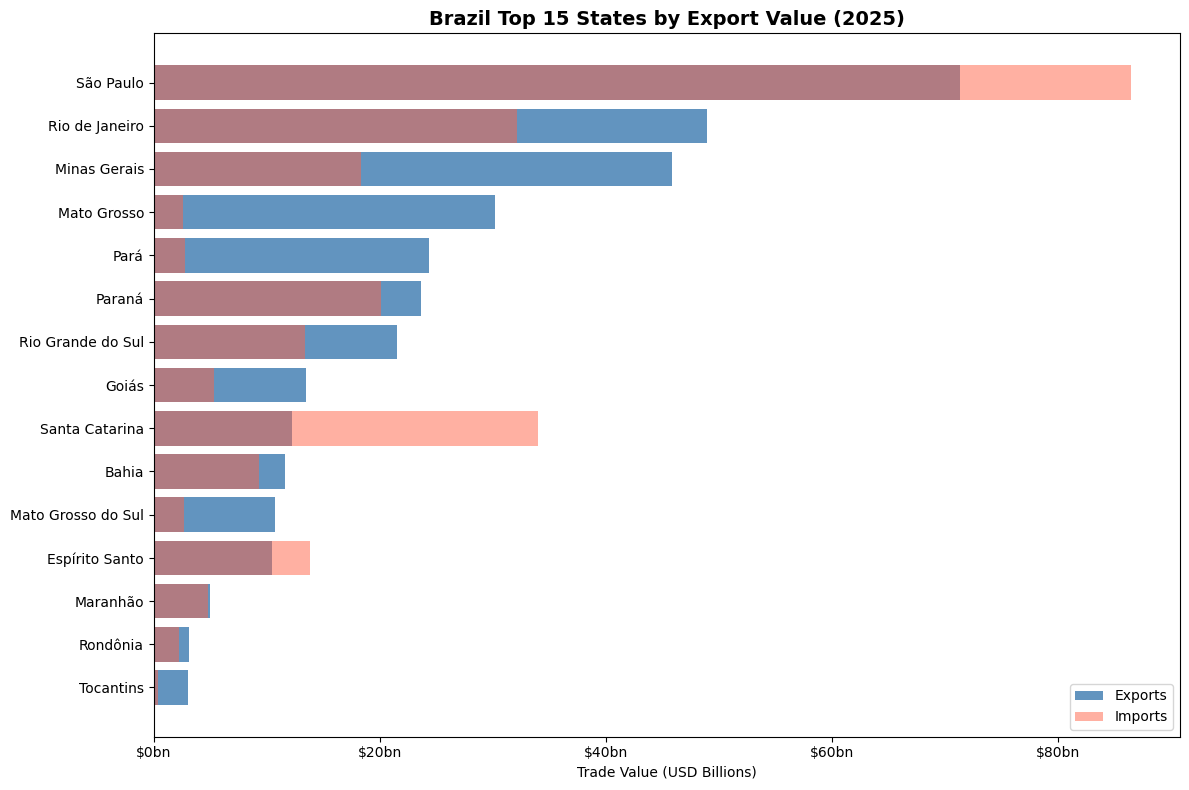


All states — Exports, Imports and Balance (2025)
              state               region uf  exports_usd_bn  imports_usd_bn  balance_usd_bn
          São Paulo       REGIAO SUDESTE SP           71.39           86.50          -15.11
     Rio de Janeiro       REGIAO SUDESTE RJ           48.98           32.17           16.80
       Minas Gerais       REGIAO SUDESTE MG           45.83           18.33           27.50
        Mato Grosso  REGIAO CENTRO OESTE MT           30.19            2.62           27.57
               Pará         REGIAO NORTE PA           24.34            2.74           21.59
             Paraná           REGIAO SUL PR           23.65           20.15            3.50
  Rio Grande do Sul           REGIAO SUL RS           21.53           13.38            8.15
              Goiás  REGIAO CENTRO OESTE GO           13.47            5.36            8.11
     Santa Catarina           REGIAO SUL SC           12.20           33.99          -21.80
              Bahia      REGIA

In [2]:
query_state_trade = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd,
           COALESCE(e.exports_usd, 0) - COALESCE(i.imports_usd, 0) AS balance_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""

df_state = pd.read_sql(query_state_trade, engine)
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
df_state['balance_usd_bn'] = (df_state['balance_usd'] / 1e9).round(2)

df_top15 = df_state.head(15).sort_values('exports_usd_bn')

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_top15['state'], df_top15['exports_usd_bn'], color='steelblue', alpha=0.85, label='Exports')
ax.barh(df_top15['state'], df_top15['imports_usd_bn'], color='tomato', alpha=0.5, label='Imports')
ax.set_title(f"Brazil Top 15 States by Export Value ({MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Value (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend()
plt.tight_layout()
plt.savefig('output_2_1_state_trade.png', dpi=150)
plt.show()

print(f"\nAll states — Exports, Imports and Balance ({MAX_YEAR})")
print(df_state[['state', 'region', 'uf', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']].to_string(index=False))

## 2.2 — Top Exporting States Over Time
How has the ranking of Brazil's top exporting states shifted from 1997 to 2025?

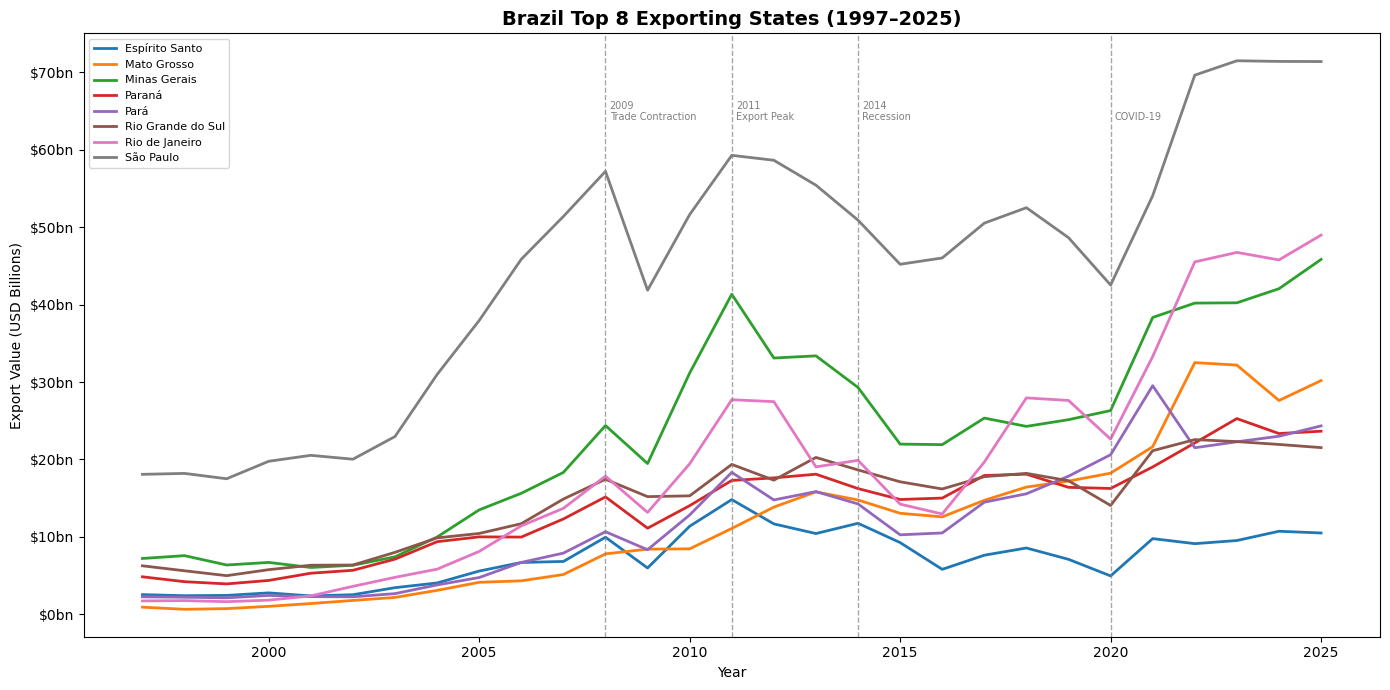

In [15]:
query_state_time = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_estado
    ORDER BY e."CO_ANO", exports_usd DESC
"""

df_state_time = pd.read_sql(query_state_time, engine)
df_state_time['exports_usd_bn'] = df_state_time['exports_usd'] / 1e9

top8_states = (
    df_state_time.groupby('state')['exports_usd']
    .sum().nlargest(8).index.tolist()
)

df_top8 = df_state_time[df_state_time['state'].isin(top8_states)]
df_pivot = df_top8.pivot(index='year', columns='state', values='exports_usd_bn').fillna(0)

## Annotate key periods identified in Step 1
events = {
    2009: ('2009\nTrade Contraction', 2008),
    2011: ('2011\nExport Peak',       2011),
    2014: ('2014\nRecession',         2014.0),
    2020: ('COVID-19',                2020)
}

fig, ax = plt.subplots(figsize=(14, 7))
for state in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[state], label=state, linewidth=2)
for year, (label, xpos) in events.items():
    ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(xpos + 0.1, ax.get_ylim()[1] * 0.85, label, fontsize=7, color='gray')

ax.set_title(f"Brazil Top 8 Exporting States (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_2_state_exports_time.png', dpi=150)
plt.show()

## 2.3 — Trade Balance by State (2025)
Which states are net exporters and which are net importers?

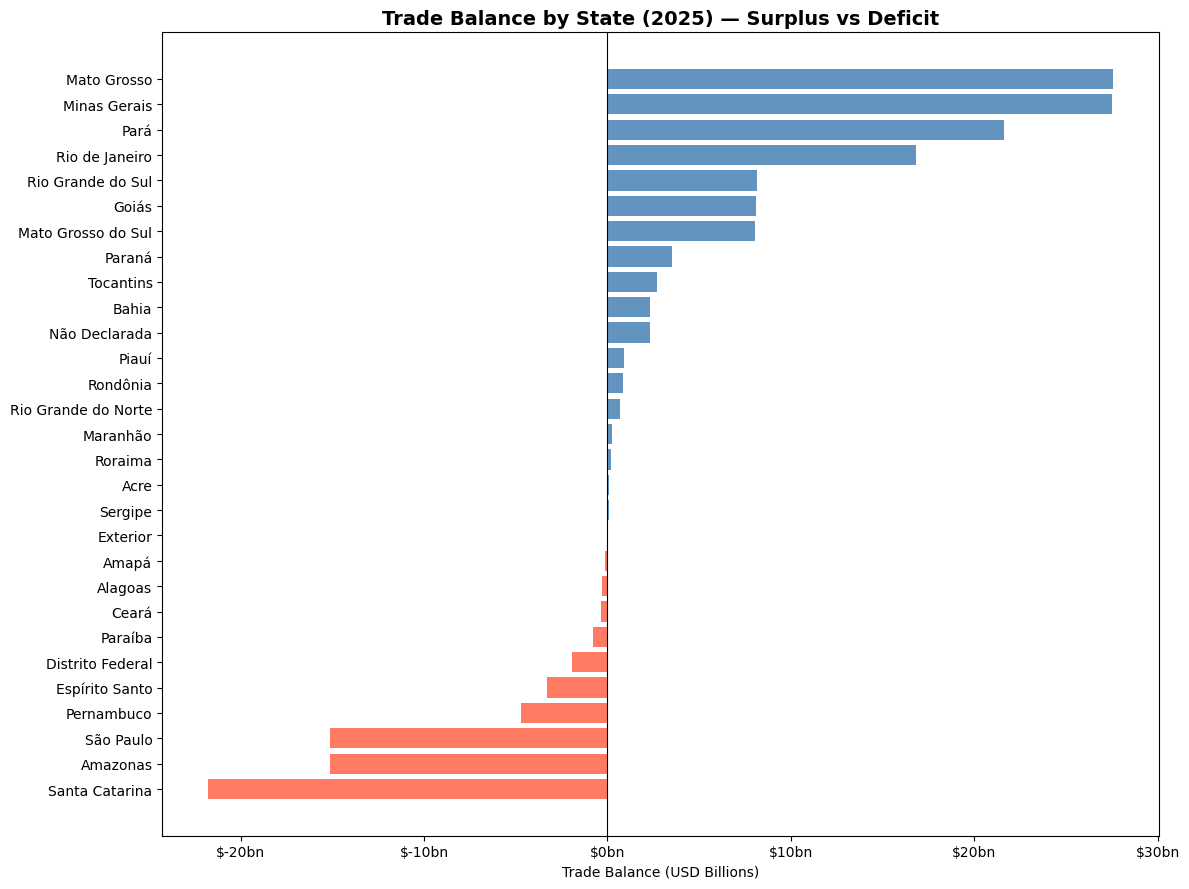

Net exporting states (2025):
              state               region  balance_usd_bn
        Mato Grosso  REGIAO CENTRO OESTE           27.57
       Minas Gerais       REGIAO SUDESTE           27.50
               Pará         REGIAO NORTE           21.59
     Rio de Janeiro       REGIAO SUDESTE           16.80
  Rio Grande do Sul           REGIAO SUL            8.15
              Goiás  REGIAO CENTRO OESTE            8.11
 Mato Grosso do Sul  REGIAO CENTRO OESTE            8.04
             Paraná           REGIAO SUL            3.50
          Tocantins         REGIAO NORTE            2.70
              Bahia      REGIAO NORDESTE            2.32
      Não Declarada REGIAO NAO DECLARADA            2.31
              Piauí      REGIAO NORDESTE            0.90
           Rondônia         REGIAO NORTE            0.85
Rio Grande do Norte      REGIAO NORDESTE            0.69
           Maranhão      REGIAO NORDESTE            0.26
            Roraima         REGIAO NORTE            0.20
  

In [4]:
## Uses df_state from 2.1
df_balance = df_state[['state', 'uf', 'region', 'balance_usd_bn']].sort_values('balance_usd_bn')
colors = ['tomato' if x < 0 else 'steelblue' for x in df_balance['balance_usd_bn']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_balance['state'], df_balance['balance_usd_bn'], color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f"Trade Balance by State ({MAX_YEAR}) — Surplus vs Deficit", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Balance (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_3_state_balance.png', dpi=150)
plt.show()

surplus_states = df_balance[df_balance['balance_usd_bn'] > 0].sort_values('balance_usd_bn', ascending=False)
deficit_states = df_balance[df_balance['balance_usd_bn'] < 0].sort_values('balance_usd_bn')

print(f"Net exporting states ({MAX_YEAR}):")
print(surplus_states[['state', 'region', 'balance_usd_bn']].to_string(index=False))
print(f"\nNet importing states ({MAX_YEAR}):")
print(deficit_states[['state', 'region', 'balance_usd_bn']].to_string(index=False))

## 2.4 — State Trade Balance Evolution Across Key Periods
Step 1 showed Brazil entered a national trade deficit around 2013. Which states drove that shift? How did state-level balances change across the key periods identified in Step 1?

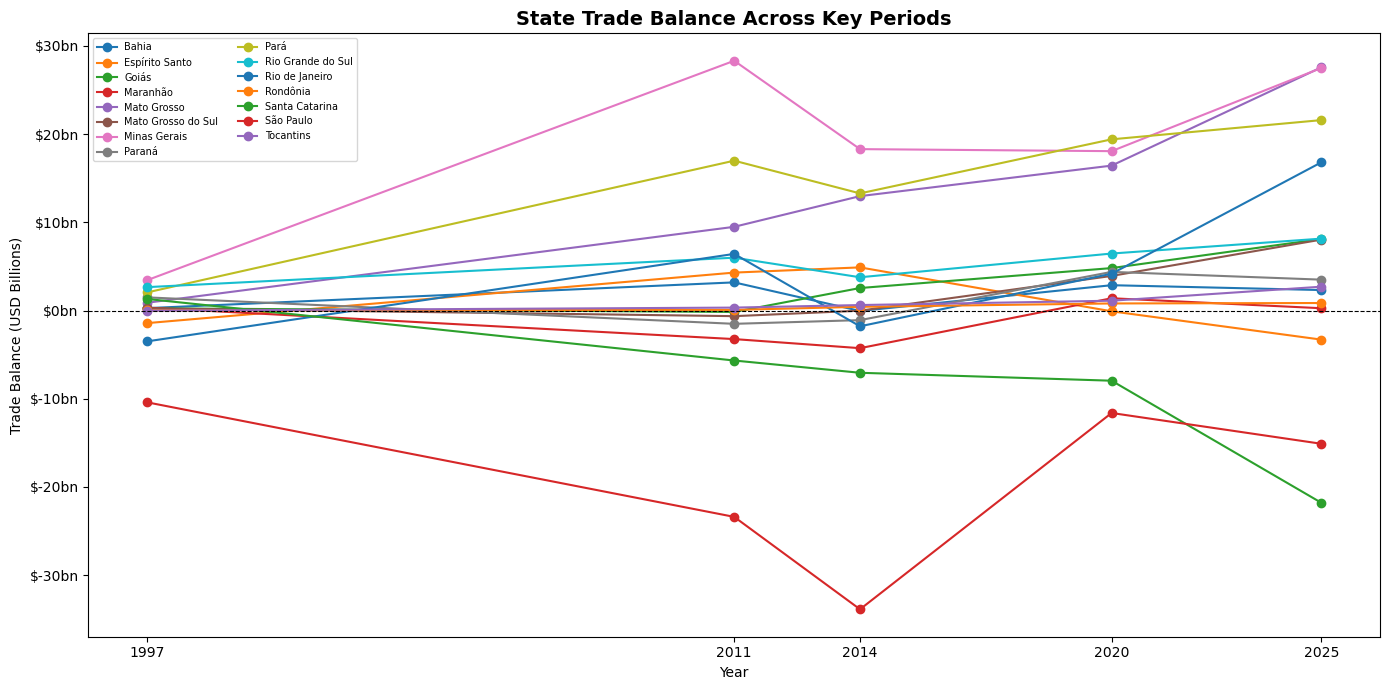


State trade balance across key periods (USD bn):
year                 1997   2011   2014   2020   2025
state                                                
Bahia                0.27   3.19  -0.05   2.87   2.32
Espírito Santo      -1.43   4.30   4.89  -0.09  -3.30
Goiás                0.25  -0.16   2.55   4.81   8.11
Maranhão             0.33  -3.24  -4.27   1.39   0.26
Mato Grosso          0.88   9.49  12.97  16.43  27.57
Mato Grosso do Sul   0.25  -0.64  -0.02   3.92   8.04
Minas Gerais         3.44  28.32  18.30  18.07  27.50
Paraná               1.49  -1.51  -1.09   4.38   3.50
Pará                 2.05  16.99  13.28  19.41  21.59
Rio Grande do Sul    2.65   5.99   3.77   6.46   8.15
Rio de Janeiro      -3.50   6.42  -1.79   4.17  16.80
Rondônia             0.02   0.07   0.42   0.80   0.85
Santa Catarina       1.31  -5.67  -7.06  -7.96 -21.80
São Paulo          -10.41 -23.40 -33.88 -11.62 -15.11
Tocantins           -0.02   0.33   0.62   1.11   2.70


In [5]:
## Key periods from Step 1 analysis
key_years = [1997, 2011, 2014, 2020, MAX_YEAR]

query_balance_periods = f"""
    SELECT year, uf, state,
           COALESCE(MAX(exports_usd), 0) - COALESCE(MAX(imports_usd), 0) AS balance_usd
    FROM (
        SELECT e."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               SUM(e."VL_FOB") AS exports_usd,
               NULL::numeric AS imports_usd
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" IN ({','.join(map(str, key_years))})
        GROUP BY e."CO_ANO", u.sigla, u.nome_estado
        UNION ALL
        SELECT i."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               NULL::numeric AS exports_usd,
               SUM(i."VL_FOB") AS imports_usd
        FROM imp i
        JOIN uf u ON i."SG_UF_NCM" = u.sigla
        WHERE i."CO_ANO" IN ({','.join(map(str, key_years))})
        GROUP BY i."CO_ANO", u.sigla, u.nome_estado
    ) t
    GROUP BY year, uf, state
"""

df_periods = pd.read_sql(query_balance_periods, engine)
df_periods['balance_usd_bn'] = (df_periods['balance_usd'] / 1e9).round(2)

## Pivot: rows = states, columns = years
df_periods_pivot = df_periods.pivot(index='state', columns='year', values='balance_usd_bn').fillna(0)

## Focus on top 15 states by absolute balance in MAX_YEAR
top15_balance = df_state.nlargest(15, 'exports_usd_bn')['state'].tolist()
df_periods_plot = df_periods_pivot.loc[df_periods_pivot.index.isin(top15_balance)]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(key_years))
width = 0.05
for i, state in enumerate(df_periods_plot.index):
    ax.plot(key_years, df_periods_plot.loc[state], marker='o', label=state, linewidth=1.5)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("State Trade Balance Across Key Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Trade Balance (USD Billions)")
ax.set_xticks(key_years)
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_4_state_balance_periods.png', dpi=150)
plt.show()

print("\nState trade balance across key periods (USD bn):")
print(df_periods_plot.to_string())

## 2.5.1 — Export Distribution by Brazilian Region
How are exports distributed across Brazil's five macro-regions? How has this shifted from 1997 to 2025?

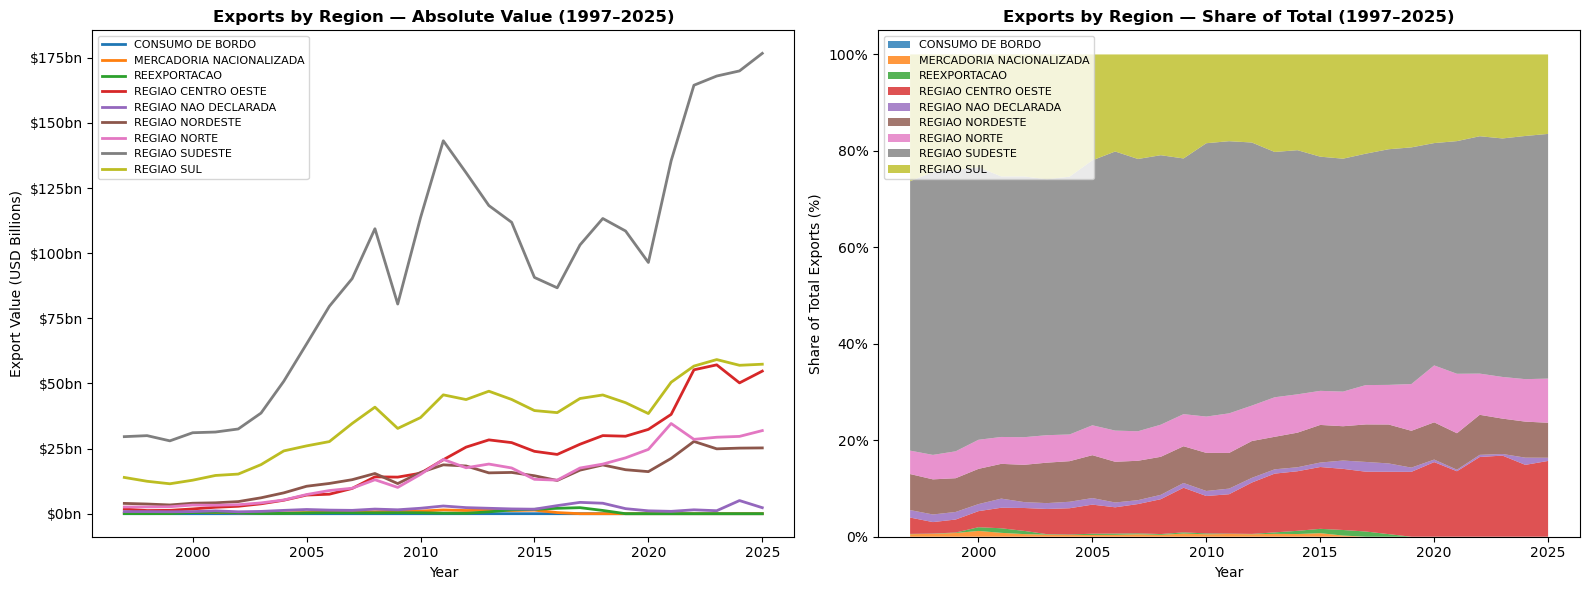


Regional export share — 1997 vs 2025
                  Region  1997 (%)  2025 (%)  Change (pp)
          REGIAO SUDESTE      55.9      50.7         -5.1
              REGIAO SUL      26.3      16.5         -9.8
     REGIAO CENTRO OESTE       3.4      15.7         12.3
            REGIAO NORTE       4.9       9.2          4.3
         REGIAO NORDESTE       7.5       7.3         -0.2
    REGIAO NAO DECLARADA       1.6       0.7         -0.9
        CONSUMO DE BORDO       0.0       0.0          0.0
MERCADORIA NACIONALIZADA       0.5       0.0         -0.5
            REEXPORTACAO       0.1       0.0         -0.1


In [6]:
query_region = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_regiao
    ORDER BY e."CO_ANO"
"""

df_region = pd.read_sql(query_region, engine)
df_region['exports_usd_bn'] = df_region['exports_usd'] / 1e9
df_region_pivot = df_region.pivot(index='year', columns='region', values='exports_usd_bn').fillna(0)
df_region_pct   = df_region_pivot.div(df_region_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for region in df_region_pivot.columns:
    ax1.plot(df_region_pivot.index, df_region_pivot[region], label=region, linewidth=2)
ax1.set_title(f"Exports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Export Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(df_region_pct.index, df_region_pct.T, labels=df_region_pct.columns, alpha=0.8)
ax2.set_title(f"Exports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Exports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('output_2_5_region_exports.png', dpi=150)
plt.show()

start_year = df_region_pct.index[0]
summary_region = pd.DataFrame({
    'Region'            : df_region_pct.columns,
    f'{start_year} (%)' : df_region_pct.loc[start_year].round(1).values,
    f'{MAX_YEAR} (%)'   : df_region_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'       : (df_region_pct.loc[MAX_YEAR] - df_region_pct.loc[start_year]).round(1).values
})
print(f"\nRegional export share — {start_year} vs {MAX_YEAR}")
print(summary_region.sort_values(f'{MAX_YEAR} (%)', ascending=False).to_string(index=False))

## 2.5.2 — Import Distribution by Brazilian Region
How are exports distributed across Brazil's five macro-regions? How has this shifted from 1997 to 2025?

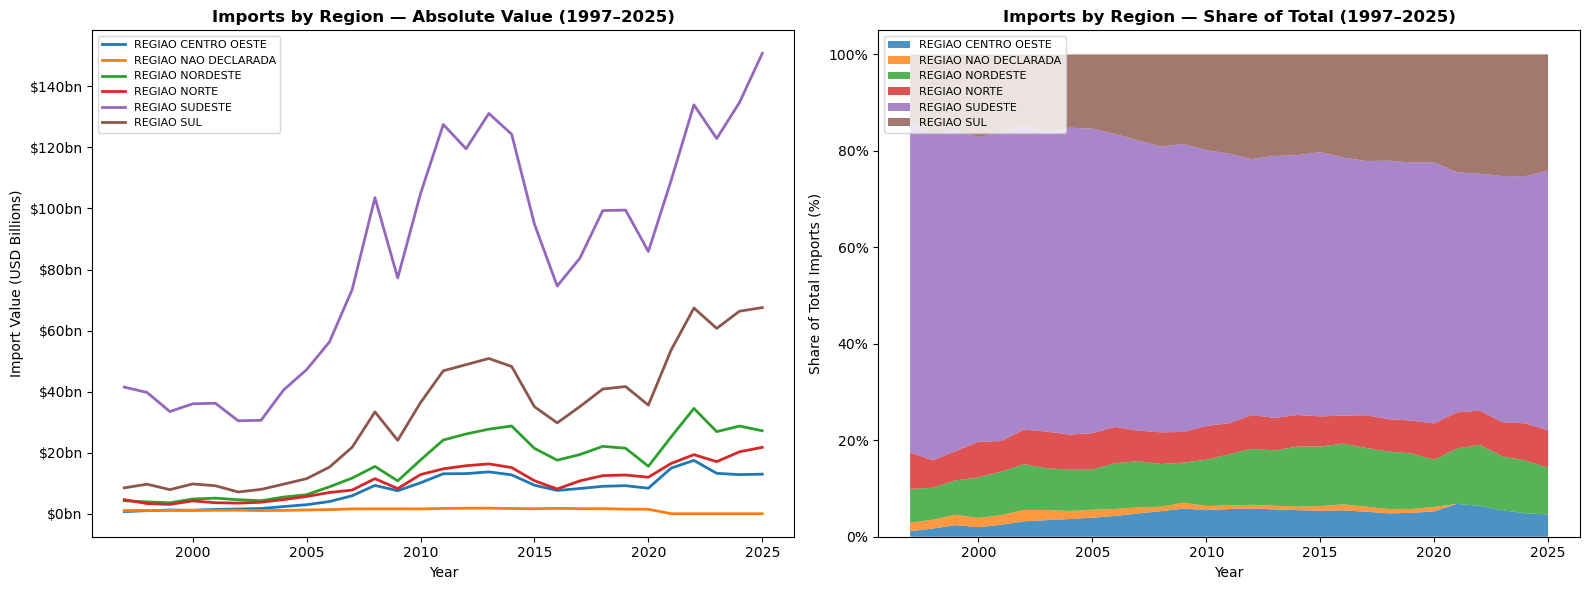


Regional import share — 1997 vs 2025
              Region  1997 (%)  2025 (%)  Change (pp)
      REGIAO SUDESTE      68.5      53.8        -14.7
          REGIAO SUL      14.0      24.1         10.1
     REGIAO NORDESTE       7.0       9.7          2.7
        REGIAO NORTE       7.6       7.8          0.2
 REGIAO CENTRO OESTE       1.1       4.6          3.5
REGIAO NAO DECLARADA       1.7       0.0         -1.7


In [16]:
query_region_imp = f"""
    SELECT i."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", u.nome_regiao
    ORDER BY i."CO_ANO"
"""

df_region_imp = pd.read_sql(query_region_imp, engine)
df_region_imp['imports_usd_bn'] = df_region_imp['imports_usd'] / 1e9
df_region_imp_pivot = df_region_imp.pivot(index='year', columns='region', values='imports_usd_bn').fillna(0)
df_region_imp_pct   = df_region_imp_pivot.div(df_region_imp_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for region in df_region_imp_pivot.columns:
    ax1.plot(df_region_imp_pivot.index, df_region_imp_pivot[region], label=region, linewidth=2)
ax1.set_title(f"Imports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Import Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(df_region_imp_pct.index, df_region_imp_pct.T, labels=df_region_imp_pct.columns, alpha=0.8)
ax2.set_title(f"Imports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Imports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('output_2_5b_region_imports.png', dpi=150)
plt.show()

start_year = df_region_imp_pct.index[0]
summary_region_imp = pd.DataFrame({
    'Region'            : df_region_imp_pct.columns,
    f'{start_year} (%)' : df_region_imp_pct.loc[start_year].round(1).values,
    f'{MAX_YEAR} (%)'   : df_region_imp_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'       : (df_region_imp_pct.loc[MAX_YEAR] - df_region_imp_pct.loc[start_year]).round(1).values
})
print(f"\nRegional import share — {start_year} vs {MAX_YEAR}")
print(summary_region_imp.sort_values(f'{MAX_YEAR} (%)', ascending=False).to_string(index=False))

## 2.6 — Top Export Sectors by State (SH2 Classification)
What are the dominant export sectors for Brazil's states?

In [7]:
top10_states_uf = df_state.head(10)['uf'].tolist()
top10_states_uf_str = ','.join([f"'{s}'" for s in top10_states_uf])

query_exp_sectors = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_exp_sectors = pd.read_sql(query_exp_sectors, engine)
df_exp_sectors['exports_usd_bn'] = (df_exp_sectors['exports_usd'] / 1e9).round(2)

df_top10_sectors = (
    df_exp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 export sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_sectors['state'].unique():
    subset = df_top10_sectors[df_top10_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2'])[:50]:<50} ${row['exports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 export sectors per state — SH2 classification (2025)

Bahia — Total exports: $11.6bn
  SH12 Sementes e frutos oleaginosos; grãos, sementes e f $2.32bn (20.0%)
  SH27 Combustíveis minerais, óleos minerais e produtos d $1.93bn (16.6%)
  SH47 Pastas de madeira ou de outras matérias fibrosas c $1.34bn (11.5%)
  SH71 Pérolas naturais ou cultivadas, pedras preciosas o $1.10bn (9.5%)
  SH52 Algodão                                            $0.93bn (8.0%)
  SH26 Minerios, escórias e cinzas                        $0.56bn (4.8%)
  SH18 Cacau e suas preparações                           $0.55bn (4.7%)
  SH9 Café, chá, mate e especiarias                      $0.49bn (4.2%)
  SH23 Resíduos e desperdícios das indústrias alimentares $0.47bn (4.0%)
  SH29 Produtos químicos orgânicos                        $0.32bn (2.7%)

Goiás — Total exports: $13.5bn
  SH12 Sementes e frutos oleaginosos; grãos, sementes e f $5.22bn (38.7%)
  SH2 Carnes e miudezas, comestíveis                     $2.73bn (20.3

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\3119887290.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


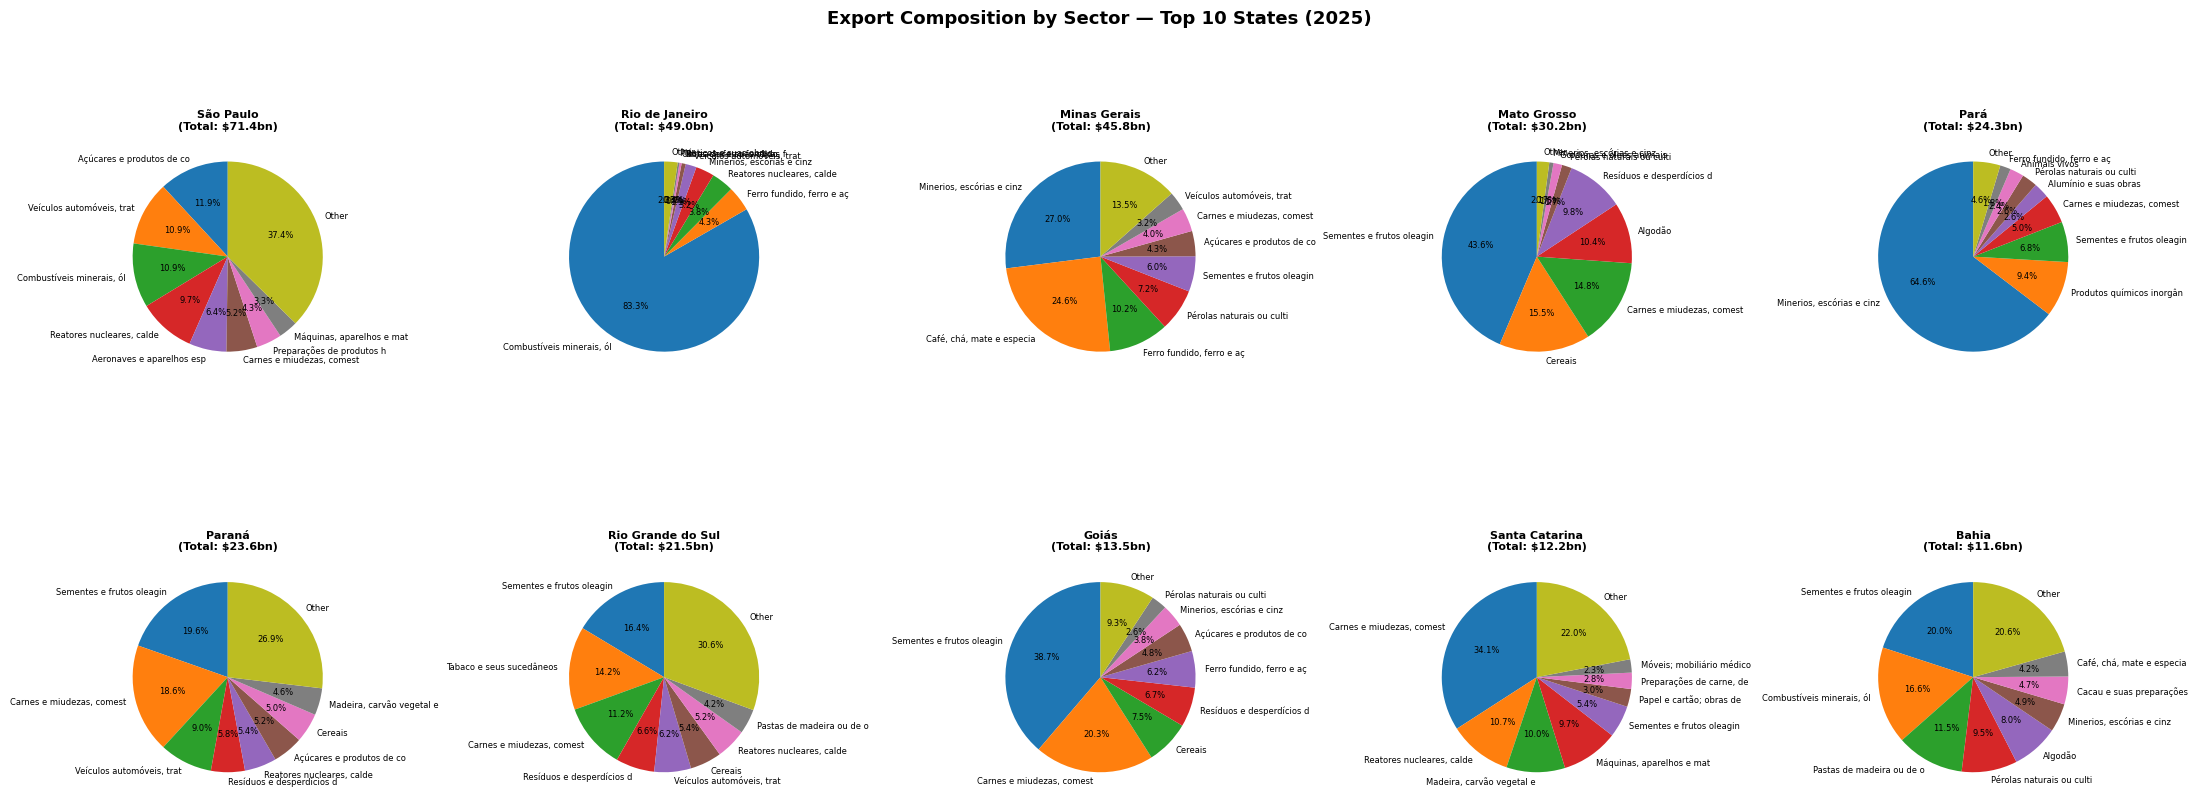

In [17]:
## Pie chart of export share by SH2 sector for each of the top 10 exporting states
top10_exp_states = df_state.head(10)['state'].tolist()
df_exp_pie = df_exp_sectors[df_exp_sectors['state'].isin(top10_exp_states)].copy()

## Group smaller sectors into 'Other' to keep charts readable
def prepare_pie(df, value_col, top_n=8):
    df = df.sort_values(value_col, ascending=False).reset_index(drop=True)
    top    = df.head(top_n).copy()
    other  = pd.DataFrame([{
        'descricao_sh2': 'Other',
        value_col      : df.iloc[top_n:][value_col].sum()
    }])
    return pd.concat([top, other], ignore_index=True)

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, state in enumerate(top10_exp_states):
    subset = df_exp_pie[df_exp_pie['state'] == state]
    total  = df_state[df_state['state'] == state]['exports_usd_bn'].iloc[0]
    pie_df = prepare_pie(subset, 'exports_usd')

    axes[i].pie(
        pie_df['exports_usd'],
        labels    = [str(s)[:25] for s in pie_df['descricao_sh2']],
        autopct   = '%1.1f%%',
        startangle= 90,
        textprops = {'fontsize': 6}
    )
    axes[i].set_title(f"{state}\n(Total: ${total:.1f}bn)", fontsize=8, fontweight='bold')

plt.suptitle(f"Export Composition by Sector — Top 10 States ({MAX_YEAR})", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_6_exp_sector_pie.png', dpi=150)
plt.show()

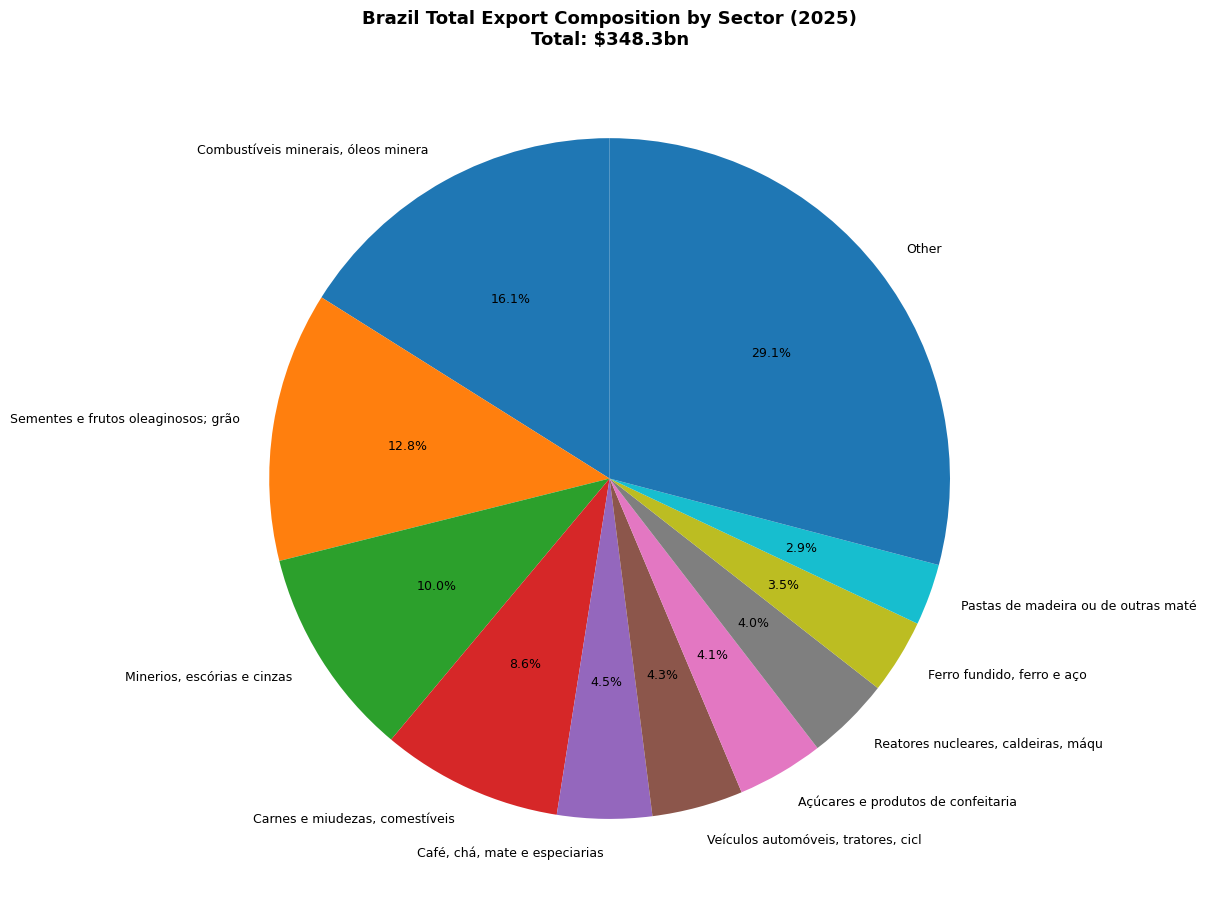


Brazil export composition by sector (2025) — Total: $348.3bn
 codigo_sh2                                                                                                                                                                                                                                                   descricao_sh2  exports_usd_bn  share
         27                                                                                                                                                        Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais           55.96   16.1
         12                                                                                                                                         Sementes e frutos oleaginosos; grãos, sementes e frutos diversos; plantas industriais ou medicinais; palhas e forragens           44.67   12.8
         26                                                      

In [20]:
## Brazil cumulative export composition by SH2 sector (MAX_YEAR)
query_brazil_exp_sectors = f"""
    SELECT s.codigo_sh2,
           s.descricao_sh2,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY s.codigo_sh2, s.descricao_sh2
    ORDER BY exports_usd DESC
"""

df_brazil_exp = pd.read_sql(query_brazil_exp_sectors, engine)
df_brazil_exp['exports_usd_bn'] = (df_brazil_exp['exports_usd'] / 1e9).round(2)
total_brazil_exp = df_brazil_exp['exports_usd_bn'].sum()

pie_brazil_exp = prepare_pie(df_brazil_exp, 'exports_usd', top_n=10)

fig, ax = plt.subplots(figsize=(12, 12))
ax.pie(
    pie_brazil_exp['exports_usd'],
    labels     = [str(s)[:35] for s in pie_brazil_exp['descricao_sh2']],
    autopct    = '%1.1f%%',
    startangle = 90,
    textprops  = {'fontsize': 9}
)
ax.set_title(f"Brazil Total Export Composition by Sector ({MAX_YEAR})\nTotal: ${total_brazil_exp:.1f}bn",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_6b_brazil_exp_sector_pie.png', dpi=150)
plt.show()

print(f"\nBrazil export composition by sector ({MAX_YEAR}) — Total: ${total_brazil_exp:.1f}bn")
print(df_brazil_exp[['codigo_sh2', 'descricao_sh2', 'exports_usd_bn']]\
      .assign(share=lambda x: (x['exports_usd_bn'] / total_brazil_exp * 100).round(1))\
      .to_string(index=False))

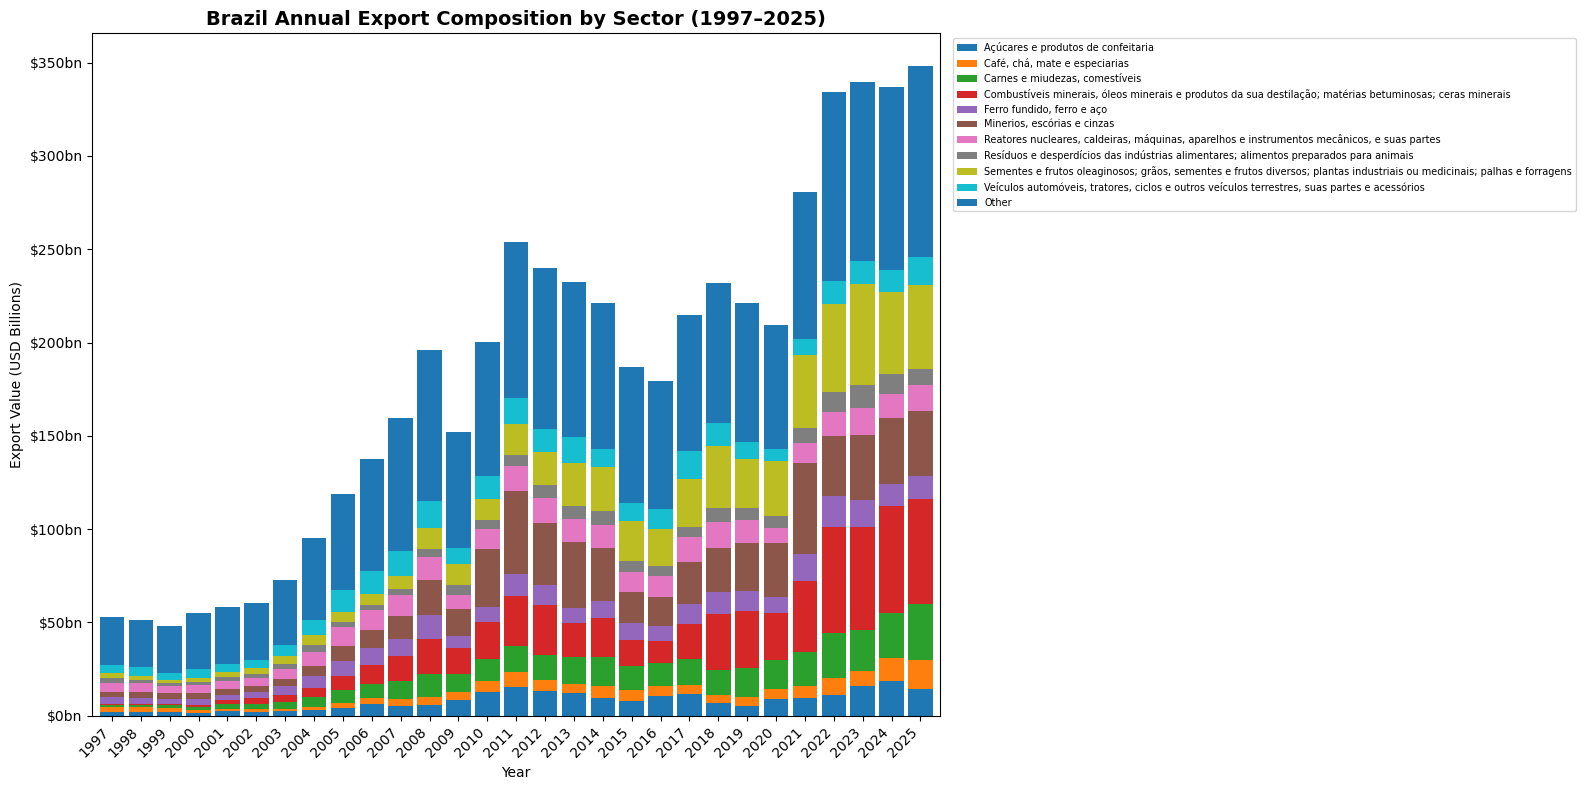


Brazil export composition by sector (2025) — Total: $348.3bn
                                                                                                                                                                                                                                                         sector  exports_usd_bn  share
                                                                                                                                                       Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais       55.955256   16.1
                                                                                                                                        Sementes e frutos oleaginosos; grãos, sementes e frutos diversos; plantas industriais ou medicinais; palhas e forragens       44.672157   12.8
                                                                                                     

In [21]:
## Brazil annual export composition by SH2 sector (1997–MAX_YEAR)
## Shows how the sectoral mix of exports has evolved over time
query_brazil_exp_annual = f"""
    SELECT e."CO_ANO" AS year,
           s.descricao_sh2 AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", s.descricao_sh2
    ORDER BY e."CO_ANO", exports_usd DESC
"""

df_brazil_exp_annual = pd.read_sql(query_brazil_exp_annual, engine)
df_brazil_exp_annual['exports_usd_bn'] = df_brazil_exp_annual['exports_usd'] / 1e9

## Identify top 10 sectors by total exports across all years — group rest as Other
top10_exp_sectors = (
    df_brazil_exp_annual.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)
df_brazil_exp_annual['sector_group'] = df_brazil_exp_annual['sector'].apply(
    lambda x: x if x in top10_exp_sectors else 'Other'
)
df_brazil_exp_grouped = (
    df_brazil_exp_annual.groupby(['year', 'sector_group'])['exports_usd_bn']
    .sum().reset_index()
)
df_brazil_exp_pivot = df_brazil_exp_grouped.pivot(
    index='year', columns='sector_group', values='exports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_exp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_exp_pivot = df_brazil_exp_pivot[cols_ordered]

fig, ax = plt.subplots(figsize=(16, 8))
df_brazil_exp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Export Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(loc='upper left', fontsize=7, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_6b_brazil_exp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBrazil export composition by sector ({MAX_YEAR}) — Total: ${df_brazil_exp_annual[df_brazil_exp_annual['year']==MAX_YEAR]['exports_usd_bn'].sum():.1f}bn")
print(df_brazil_exp_annual[df_brazil_exp_annual['year'] == MAX_YEAR]\
      .groupby('sector')['exports_usd_bn'].sum()\
      .sort_values(ascending=False)\
      .reset_index()\
      .assign(share=lambda x: (x['exports_usd_bn'] / x['exports_usd_bn'].sum() * 100).round(1))\
      .to_string(index=False))

## 2.7 — Top Import Sectors by State (SH2 Classification)
What are the dominant import sectors for Brazil's states?

In [8]:
top10_imp_states_uf = df_state.nlargest(10, 'imports_usd_bn')['uf'].tolist()
top10_imp_states_uf_str = ','.join([f"'{s}'" for s in top10_imp_states_uf])

query_imp_sectors = f"""
    SELECT i."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY i."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2
    ORDER BY i."SG_UF_NCM", imports_usd DESC
"""

df_imp_sectors = pd.read_sql(query_imp_sectors, engine)
df_imp_sectors['imports_usd_bn'] = (df_imp_sectors['imports_usd'] / 1e9).round(2)

df_top10_imp_sectors = (
    df_imp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'imports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 import sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_imp_sectors['state'].unique():
    subset = df_top10_imp_sectors[df_top10_imp_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['imports_usd_bn'].iloc[0]
    print(f"\n{state} — Total imports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['imports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2'])[:50]:<50} ${row['imports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 import sectors per state — SH2 classification (2025)

Amazonas — Total imports: $16.1bn
  SH85 Máquinas, aparelhos e materiais elétricos, e suas  $7.06bn (44.0%)
  SH84 Reatores nucleares, caldeiras, máquinas, aparelhos $2.23bn (13.9%)
  SH39 Plásticos e suas obras                             $1.26bn (7.9%)
  SH27 Combustíveis minerais, óleos minerais e produtos d $1.16bn (7.2%)
  SH71 Pérolas naturais ou cultivadas, pedras preciosas o $0.91bn (5.7%)
  SH87 Veículos automóveis, tratores, ciclos e outros veí $0.90bn (5.6%)
  SH29 Produtos químicos orgânicos                        $0.39bn (2.4%)
  SH72 Ferro fundido, ferro e aço                         $0.39bn (2.4%)
  SH90 Instrumentos e aparelhos de óptica, de fotografia, $0.31bn (1.9%)
  SH40 Borracha e suas obras                              $0.22bn (1.3%)

Bahia — Total imports: $9.3bn
  SH27 Combustíveis minerais, óleos minerais e produtos d $4.08bn (43.8%)
  SH31 Adubos (fertilizantes)                             $0.98bn (1

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\381018430.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'imports_usd'))


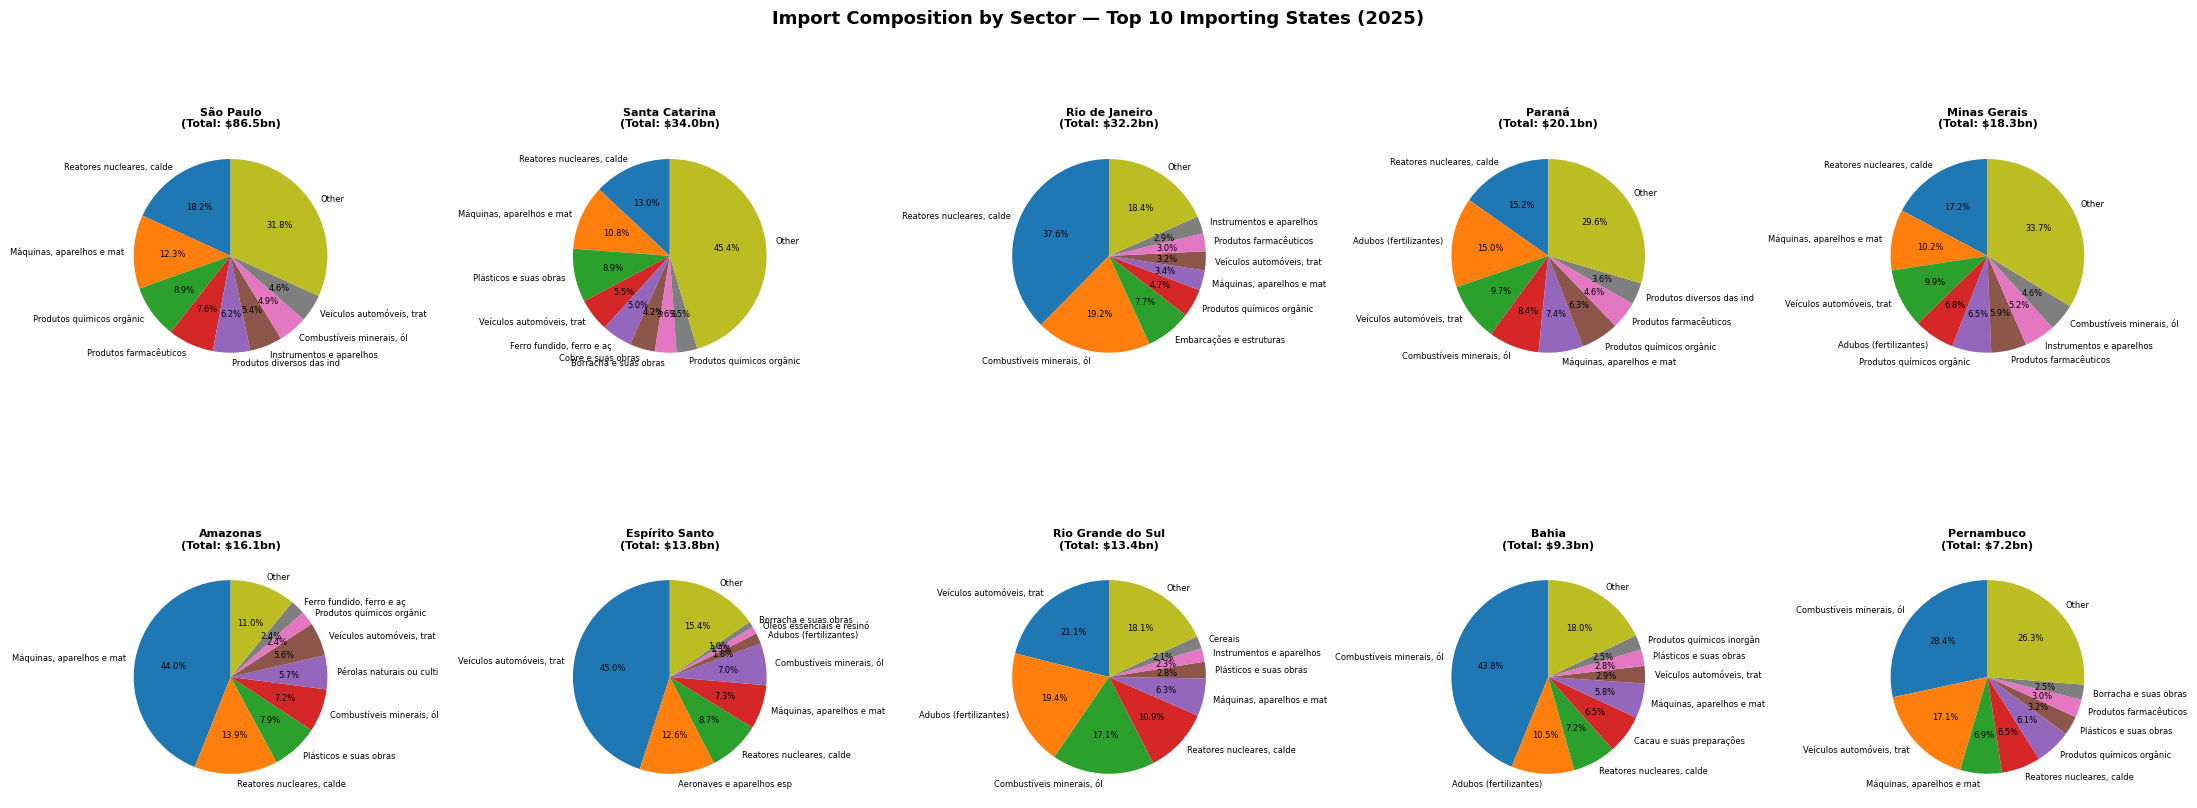

In [18]:
## Pie chart of import share by SH2 sector for each of the top 10 importing states
top10_imp_states = df_state.nlargest(10, 'imports_usd_bn')['state'].tolist()
df_imp_pie = df_imp_sectors[df_imp_sectors['state'].isin(top10_imp_states)].copy()

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, state in enumerate(top10_imp_states):
    subset = df_imp_pie[df_imp_pie['state'] == state]
    total  = df_state[df_state['state'] == state]['imports_usd_bn'].iloc[0]
    pie_df = prepare_pie(subset, 'imports_usd')

    axes[i].pie(
        pie_df['imports_usd'],
        labels    = [str(s)[:25] for s in pie_df['descricao_sh2']],
        autopct   = '%1.1f%%',
        startangle= 90,
        textprops = {'fontsize': 6}
    )
    axes[i].set_title(f"{state}\n(Total: ${total:.1f}bn)", fontsize=8, fontweight='bold')

plt.suptitle(f"Import Composition by Sector — Top 10 Importing States ({MAX_YEAR})", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_7_imp_sector_pie.png', dpi=150)
plt.show()

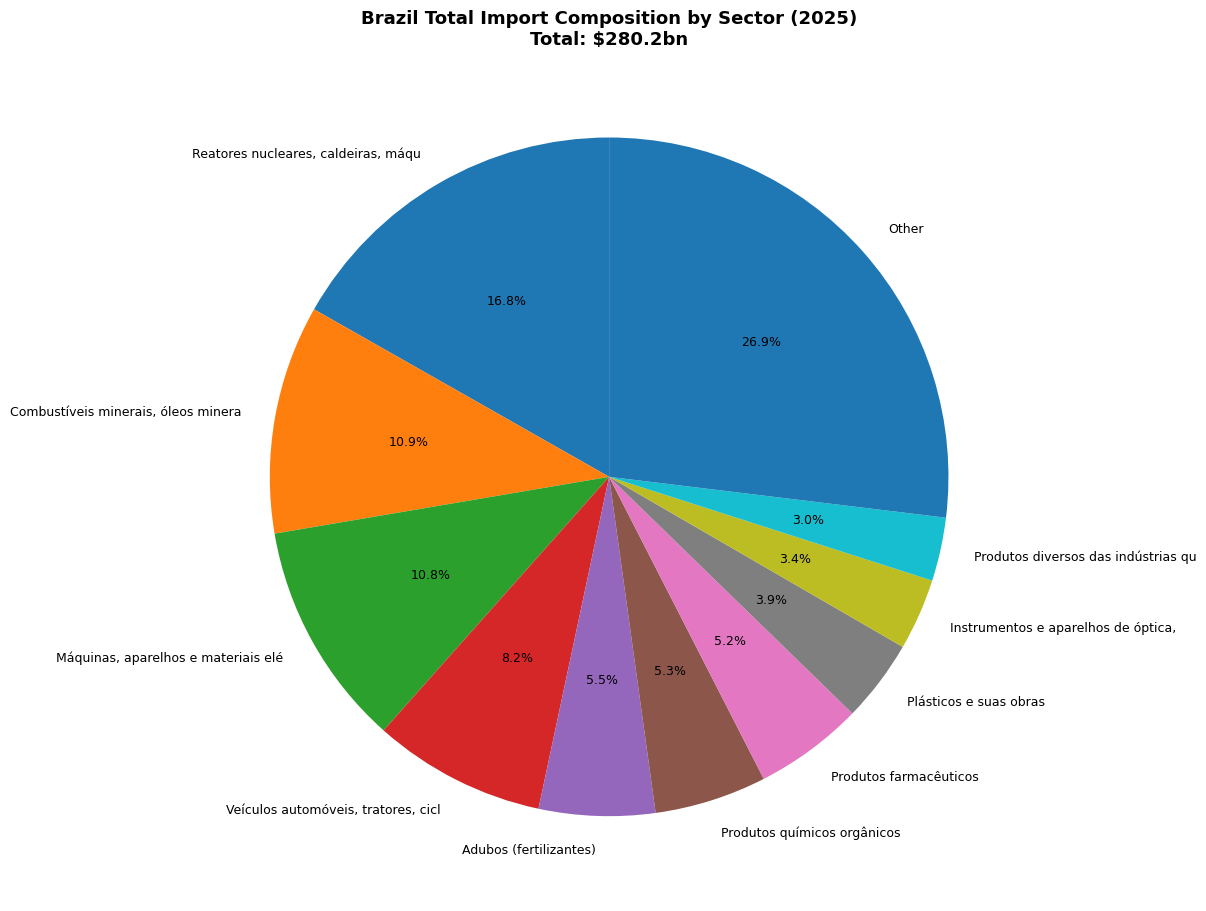


Brazil import composition by sector (2025) — Total: $280.2bn
 codigo_sh2                                                                                                                                                                                                                                                   descricao_sh2  imports_usd_bn  share
         84                                                                                                                                                                      Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes           47.03   16.8
         27                                                                                                                                                        Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais           30.53   10.9
         85                                                    Má

In [19]:
## Brazil cumulative import composition by SH2 sector (MAX_YEAR)
query_brazil_imp_sectors = f"""
    SELECT s.codigo_sh2,
           s.descricao_sh2,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY s.codigo_sh2, s.descricao_sh2
    ORDER BY imports_usd DESC
"""

df_brazil_imp = pd.read_sql(query_brazil_imp_sectors, engine)
df_brazil_imp['imports_usd_bn'] = (df_brazil_imp['imports_usd'] / 1e9).round(2)
total_brazil_imp = df_brazil_imp['imports_usd_bn'].sum()

pie_brazil_imp = prepare_pie(df_brazil_imp, 'imports_usd', top_n=10)

fig, ax = plt.subplots(figsize=(12, 12))
ax.pie(
    pie_brazil_imp['imports_usd'],
    labels     = [str(s)[:35] for s in pie_brazil_imp['descricao_sh2']],
    autopct    = '%1.1f%%',
    startangle = 90,
    textprops  = {'fontsize': 9}
)
ax.set_title(f"Brazil Total Import Composition by Sector ({MAX_YEAR})\nTotal: ${total_brazil_imp:.1f}bn",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_7b_brazil_imp_sector_pie.png', dpi=150)
plt.show()

print(f"\nBrazil import composition by sector ({MAX_YEAR}) — Total: ${total_brazil_imp:.1f}bn")
print(df_brazil_imp[['codigo_sh2', 'descricao_sh2', 'imports_usd_bn']]\
      .assign(share=lambda x: (x['imports_usd_bn'] / total_brazil_imp * 100).round(1))\
      .to_string(index=False))

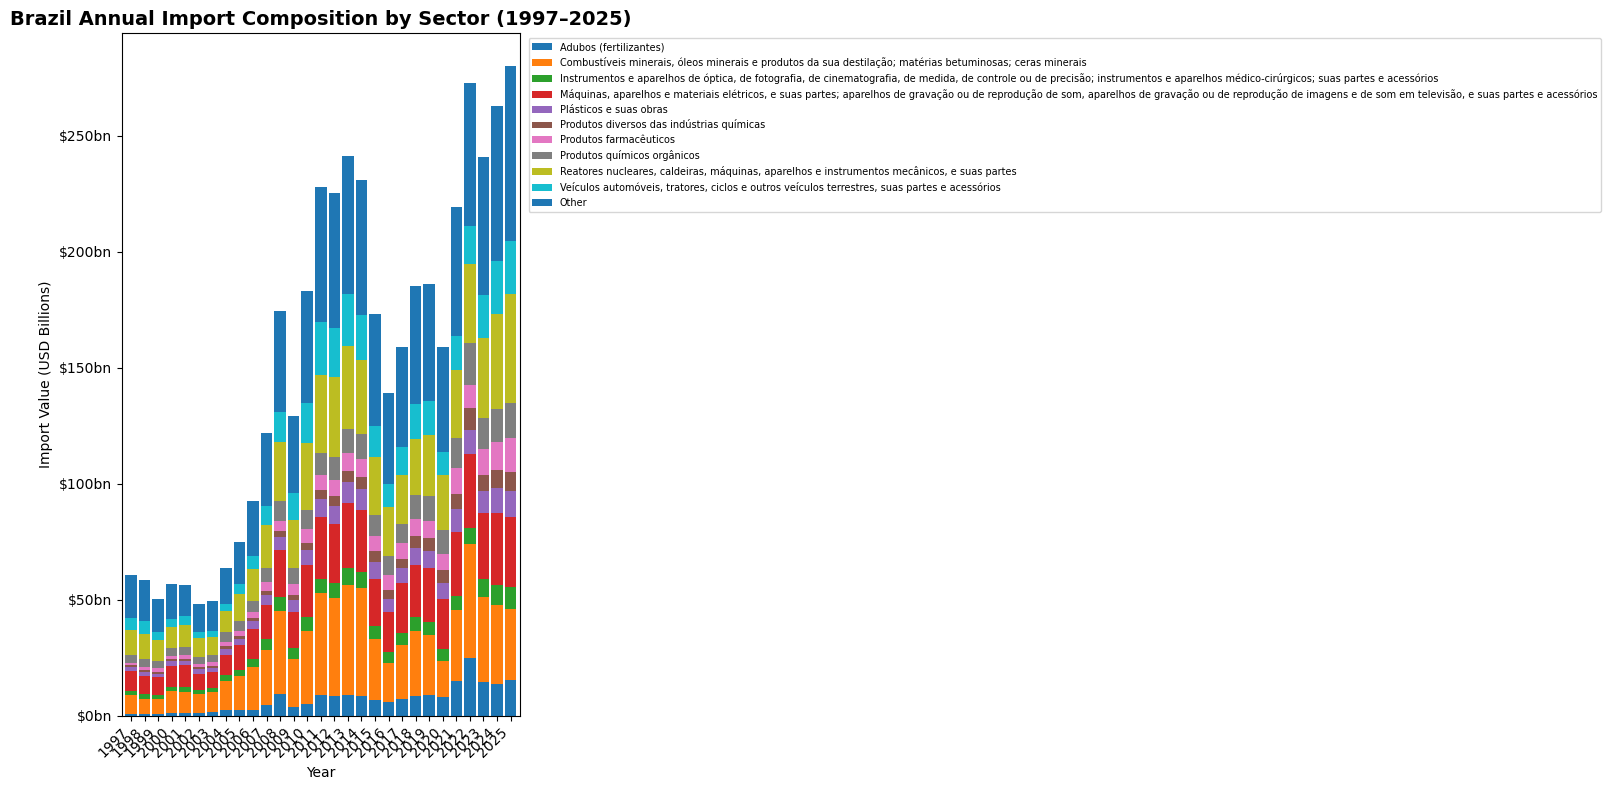


Brazil import composition by sector (2025) — Total: $280.2bn
                                                                                                                                                                                                                                                         sector  imports_usd_bn  share
                                                                                                                                                                     Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes       47.029045   16.8
                                                                                                                                                       Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais       30.526234   10.9
                                                   Máquinas, aparelhos e materiais elétricos, e suas 

In [22]:
## Brazil annual import composition by SH2 sector (1997–MAX_YEAR)
query_brazil_imp_annual = f"""
    SELECT i."CO_ANO" AS year,
           s.descricao_sh2 AS sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", s.descricao_sh2
    ORDER BY i."CO_ANO", imports_usd DESC
"""

df_brazil_imp_annual = pd.read_sql(query_brazil_imp_annual, engine)
df_brazil_imp_annual['imports_usd_bn'] = df_brazil_imp_annual['imports_usd'] / 1e9

## Identify top 10 sectors by total imports across all years — group rest as Other
top10_imp_sectors = (
    df_brazil_imp_annual.groupby('sector')['imports_usd']
    .sum().nlargest(10).index.tolist()
)
df_brazil_imp_annual['sector_group'] = df_brazil_imp_annual['sector'].apply(
    lambda x: x if x in top10_imp_sectors else 'Other'
)
df_brazil_imp_grouped = (
    df_brazil_imp_annual.groupby(['year', 'sector_group'])['imports_usd_bn']
    .sum().reset_index()
)
df_brazil_imp_pivot = df_brazil_imp_grouped.pivot(
    index='year', columns='sector_group', values='imports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_imp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_imp_pivot = df_brazil_imp_pivot[cols_ordered]

fig, ax = plt.subplots(figsize=(16, 8))
df_brazil_imp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Import Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Import Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(loc='upper left', fontsize=7, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_7b_brazil_imp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBrazil import composition by sector ({MAX_YEAR}) — Total: ${df_brazil_imp_annual[df_brazil_imp_annual['year']==MAX_YEAR]['imports_usd_bn'].sum():.1f}bn")
print(df_brazil_imp_annual[df_brazil_imp_annual['year'] == MAX_YEAR]\
      .groupby('sector')['imports_usd_bn'].sum()\
      .sort_values(ascending=False)\
      .reset_index()\
      .assign(share=lambda x: (x['imports_usd_bn'] / x['imports_usd_bn'].sum() * 100).round(1))\
      .to_string(index=False))

## 2.8 — Top NCM Products by State and Region
Beyond sector-level SH2 classification — what are the specific top 10 NCM products for each of the states and each region?

In [9]:
## ---- TOP NCM BY STATE ----
query_ncm_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, e."CO_NCM", n.nome_ncm
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_ncm_state = pd.read_sql(query_ncm_state, engine)
df_ncm_state['exports_usd_bn'] = (df_ncm_state['exports_usd'] / 1e9).round(3)

df_top10_ncm_state = (
    df_ncm_state.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 NCM products by state ({MAX_YEAR})")
for state in df_top10_ncm_state['state'].unique():
    subset = df_top10_ncm_state[df_top10_ncm_state['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

## ---- TOP NCM BY REGION ----
query_ncm_region = f"""
    SELECT u.nome_regiao AS region,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, e."CO_NCM", n.nome_ncm
    ORDER BY u.nome_regiao, exports_usd DESC
"""

df_ncm_region = pd.read_sql(query_ncm_region, engine)
df_ncm_region['exports_usd_bn'] = (df_ncm_region['exports_usd'] / 1e9).round(3)

df_top10_ncm_region = (
    df_ncm_region.groupby('region', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

## Regional totals
region_totals = df_region[df_region['year'] == MAX_YEAR].set_index('region')['exports_usd']

print(f"\nTop 10 NCM products by region ({MAX_YEAR})")
for region in df_top10_ncm_region['region'].unique():
    subset = df_top10_ncm_region[df_top10_ncm_region['region'] == region]
    total  = region_totals.get(region, 1)
    print(f"\n{region} — Total exports: ${total/1e9:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / total * 100)
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\1825458533.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


Top 10 NCM products by state (2025)

Bahia — Total exports: $11.6bn
  NCM 12019000 Soja, mesmo triturada, exceto para semeadura       $2.314bn (19.9%)
  NCM 27101922 Fuel oil                                           $1.592bn (13.7%)
  NCM 71081210 Bulhão dourado (bullion doré), em formas brutas, p $1.072bn (9.2%)
  NCM 47032900 Pastas químicas de madeira, à soda ou ao sulfato,  $1.004bn (8.6%)
  NCM 52010020 Algodão não cardado nem penteado, simplesmente deb $0.933bn (8.0%)
  NCM 9011110 Café não torrado, não descafeinado, em grão        $0.397bn (3.4%)
  NCM 23040090 Bagaços e outros resíduos sólidos, da extração do  $0.362bn (3.1%)
  NCM 47020000 Pasta química de madeira, para dissolução          $0.337bn (2.9%)
  NCM 26030010 Sulfetos de minérios de cobre e seus concentrados  $0.303bn (2.6%)
  NCM 27101921 Gasóleo (óleo diesel)                              $0.287bn (2.5%)

Goiás — Total exports: $13.5bn
  NCM 12019000 Soja, mesmo triturada, exceto para semeadura       $5.190bn (38.

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\1825458533.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


## 2.9 — State-Level China Dependency
Step 1 showed China absorbs 28.7% of Brazil's total exports. Is this uniform across all states or concentrated in specific ones?

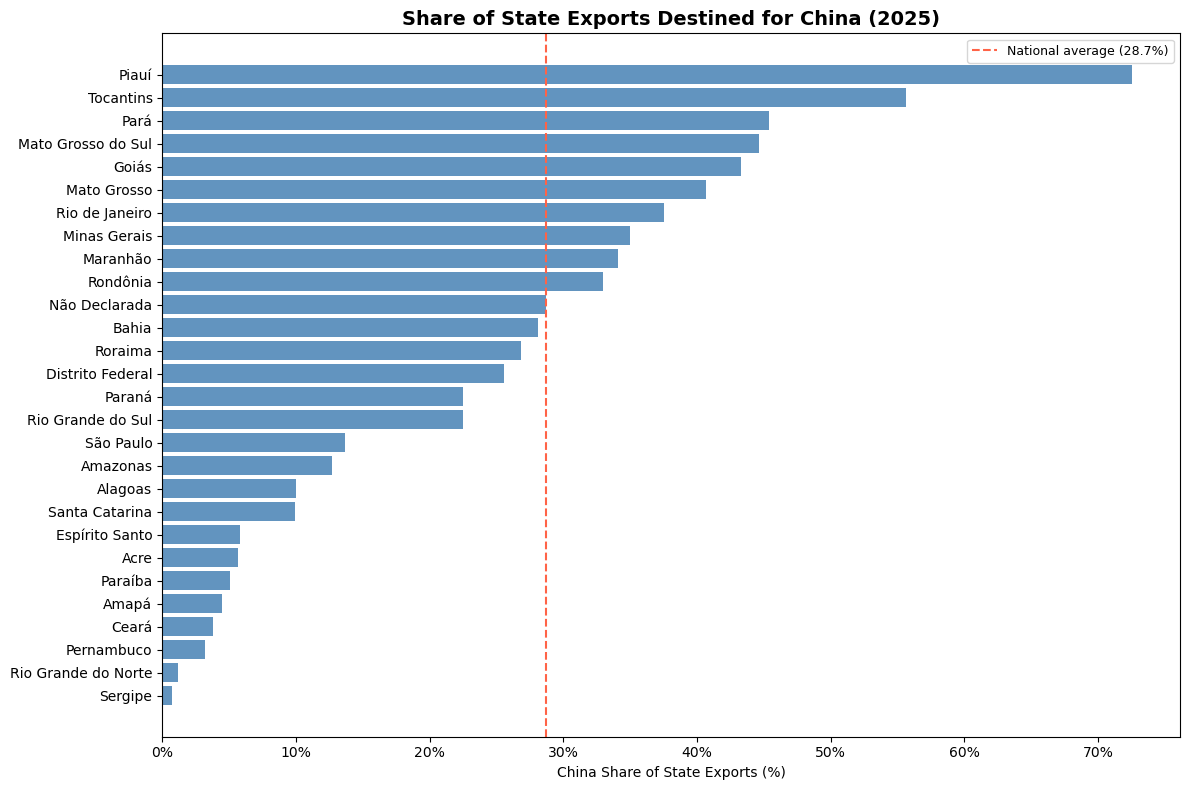


China dependency by state (2025) — national average: 28.7%
              state  exports_to_china_bn  exports_usd_bn  china_share_%
              Piauí                 0.87            1.20           72.5
          Tocantins                 1.70            3.05           55.6
               Pará                11.04           24.34           45.4
 Mato Grosso do Sul                 4.80           10.75           44.6
              Goiás                 5.83           13.47           43.3
        Mato Grosso                12.29           30.19           40.7
     Rio de Janeiro                18.38           48.98           37.5
       Minas Gerais                16.06           45.83           35.0
           Maranhão                 1.71            5.02           34.1
           Rondônia                 1.02            3.09           33.0
      Não Declarada                 0.66            2.31           28.7
              Bahia                 3.27           11.63           28.1
    

In [10]:
china_code_query = "SELECT codigo_pais FROM pais WHERE nome_pais_ing = 'China'"
china_code = pd.read_sql(china_code_query, engine)['codigo_pais'].iloc[0]

query_china_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_to_china
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."CO_PAIS" = {china_code}
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY exports_to_china DESC
"""

df_china_state = pd.read_sql(query_china_state, engine)
df_china_state['exports_to_china_bn'] = (df_china_state['exports_to_china'] / 1e9).round(2)

df_china_share = df_china_state.merge(
    df_state[['uf', 'exports_usd', 'exports_usd_bn']], on='uf', how='left'
)
df_china_share['china_share_%'] = (
    df_china_share['exports_to_china'] / df_china_share['exports_usd'] * 100
).round(1)

df_china_plot = df_china_share.sort_values('china_share_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_china_plot['state'], df_china_plot['china_share_%'], color='steelblue', alpha=0.85)
ax.axvline(x=28.7, color='tomato', linestyle='--', linewidth=1.5, label='National average (28.7%)')
ax.set_title(f"Share of State Exports Destined for China ({MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("China Share of State Exports (%)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('output_2_9_china_dependency.png', dpi=150)
plt.show()

print(f"\nChina dependency by state ({MAX_YEAR}) — national average: 28.7%")
print(df_china_share[['state', 'exports_to_china_bn', 'exports_usd_bn', 'china_share_%']]
      .sort_values('china_share_%', ascending=False)
      .to_string(index=False))

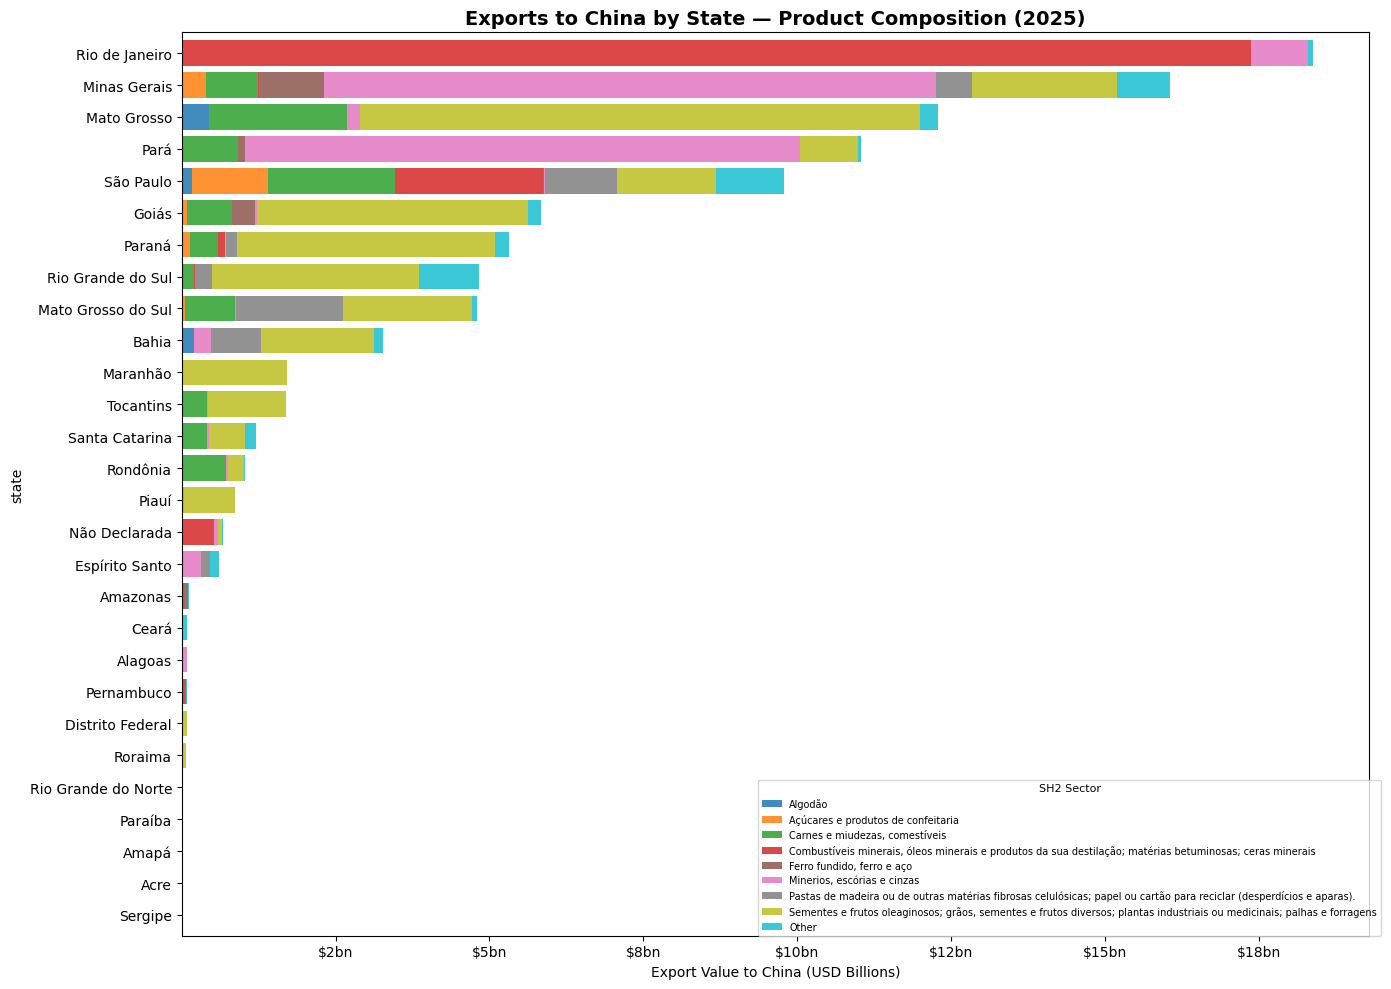


Top 3 sectors exported to China by state (2025)

Mato Grosso — Total to China: $12.29bn
  Sementes e frutos oleaginosos; grãos, sementes e f $9.10bn (74.0%)
  Carnes e miudezas, comestíveis                     $2.25bn (18.3%)
  Algodão                                            $0.44bn (3.6%)

Bahia — Total to China: $3.27bn
  Sementes e frutos oleaginosos; grãos, sementes e f $1.84bn (56.3%)
  Pastas de madeira ou de outras matérias fibrosas c $0.81bn (24.8%)
  Minerios, escórias e cinzas                        $0.29bn (8.8%)

São Paulo — Total to China: $9.78bn
  Combustíveis minerais, óleos minerais e produtos d $2.42bn (24.7%)
  Carnes e miudezas, comestíveis                     $2.05bn (21.0%)
  Sementes e frutos oleaginosos; grãos, sementes e f $1.62bn (16.5%)

Santa Catarina — Total to China: $1.20bn
  Sementes e frutos oleaginosos; grãos, sementes e f $0.58bn (48.3%)
  Carnes e miudezas, comestíveis                     $0.40bn (33.7%)
  Madeira, carvão vegetal e obras de madei

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\931519619.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'exports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\931519619.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'exports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\931519619.py:71: RuntimeWarning: divide 

In [24]:
## Stacked horizontal bar — exports to China by state, shaded by SH2 sector
## Shows the product composition of each state's exports to China

## Pivot: rows = states, columns = sectors, values = exports to China in USD bn
df_china_sh2['exports_usd_bn'] = df_china_sh2['exports_usd'] / 1e9

## Keep top 8 sectors by total value across all states — group rest as Other
top8_china_sectors = (
    df_china_sh2.groupby('sector')['exports_usd']
    .sum().nlargest(8).index.tolist()
)
df_china_sh2['sector_group'] = df_china_sh2['sector'].apply(
    lambda x: x if x in top8_china_sectors else 'Other'
)
df_china_sh2_grouped = (
    df_china_sh2.groupby(['state', 'sector_group'])['exports_usd_bn']
    .sum().reset_index()
)
df_china_stacked = df_china_sh2_grouped.pivot(
    index='state', columns='sector_group', values='exports_usd_bn'
).fillna(0)

## Reorder states by total exports to China (descending)
df_china_stacked['_total'] = df_china_stacked.sum(axis=1)
df_china_stacked = df_china_stacked.sort_values('_total', ascending=True).drop(columns='_total')

## Put Other last
cols_ordered = [c for c in df_china_stacked.columns if c != 'Other'] + \
               (['Other'] if 'Other' in df_china_stacked.columns else [])
df_china_stacked = df_china_stacked[cols_ordered]

## Add national average share line — convert to USD for positioning
national_avg_line = df_china_share.set_index('state')['china_share_%']

fig, ax = plt.subplots(figsize=(14, 10))
df_china_stacked.plot(kind='barh', stacked=True, ax=ax, width=0.8,
                      colormap='tab10', alpha=0.85)

## Overlay national average as a reference annotation
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title(f"Exports to China by State — Product Composition ({MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Export Value to China (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(loc='lower right', fontsize=7,
          title='SH2 Sector', title_fontsize=8,
          bbox_to_anchor=(1.01, 0), borderaxespad=0)
plt.tight_layout()
plt.savefig('output_2_9b_china_dependency_sh2_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table — top 3 sectors per state for exports to China
df_top3_china = (
    df_china_sh2.groupby(['state', 'sector'], group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'exports_usd'))
    .reset_index(drop=True)
)
df_top3_china['exports_usd_bn'] = (df_top3_china['exports_usd'] / 1e9).round(2)

print(f"\nTop 3 sectors exported to China by state ({MAX_YEAR})")
for state in df_china_stacked.sort_values(df_china_stacked.columns[0],
                                           ascending=False).index:
    subset = df_top3_china[df_top3_china['state'] == state]
    if subset.empty:
        continue
    total_to_china = df_china_share[df_china_share['state'] == state]['exports_to_china_bn'].iloc[0]
    print(f"\n{state} — Total to China: ${total_to_china:.2f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total_to_china * 1e9) * 100)
        print(f"  {str(row['sector'])[:50]:<50} ${row['exports_usd_bn']:.2f}bn ({share:.1f}%)")

## 2.10 — Monthly Export Variation by State (Box Plot)
How much do monthly export values vary for each state? Uses the last 10 years (2016–2025) to capture recent structural patterns. A wide box indicates high seasonal or cyclical volatility; a narrow box indicates consistent monthly flows.

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\4254290742.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax_states.boxplot(
C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\4254290742.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax_brazil.boxplot(
C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\4254290742.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


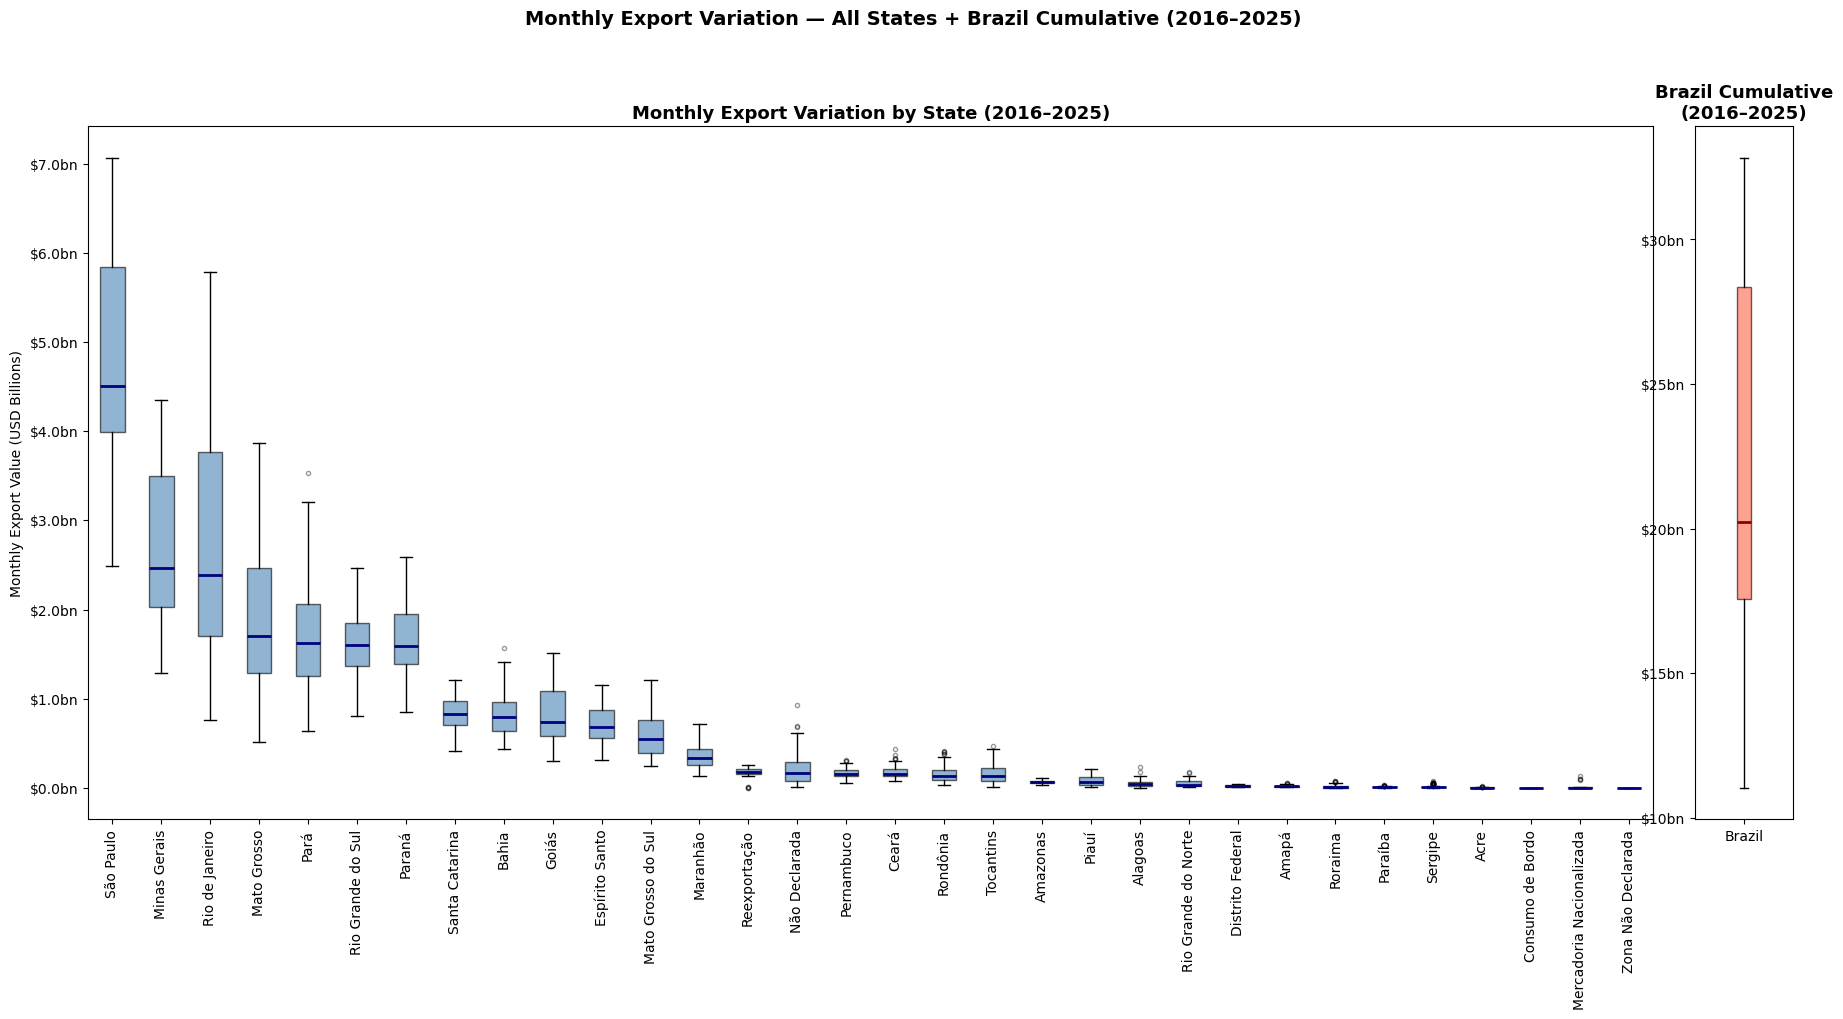


Monthly export summary statistics by state (2016–2025)
                          median  mean   std   min   max
state                                                   
São Paulo                   4.51  4.82  1.07  2.48  7.06
Minas Gerais                2.47  2.75  0.80  1.29  4.35
Rio de Janeiro              2.39  2.76  1.21  0.77  5.79
Mato Grosso                 1.71  1.86  0.76  0.51  3.87
Pará                        1.63  1.66  0.54  0.64  3.54
Rio Grande do Sul           1.61  1.61  0.37  0.81  2.46
Paraná                      1.59  1.64  0.38  0.85  2.59
Santa Catarina              0.82  0.83  0.17  0.41  1.21
Bahia                       0.80  0.82  0.23  0.44  1.56
Goiás                       0.74  0.82  0.32  0.31  1.52
Espírito Santo              0.68  0.70  0.20  0.32  1.15
Mato Grosso do Sul          0.55  0.60  0.24  0.24  1.21
Maranhão                    0.33  0.35  0.13  0.13  0.72
Reexportação                0.18  0.17  0.07  0.00  0.25
Não Declarada               0.17

In [26]:
## Monthly export variation — box plot for all states + Brazil cumulative
## Window: 2016–2025 (last 10 years)

query_monthly_exp_all = f"""
    SELECT e."CO_ANO" AS year,
           e."CO_MES" AS month,
           u.nome_estado AS state,
           u.sigla AS uf,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM\" = u.sigla
    WHERE e."CO_ANO" BETWEEN {BOX_START} AND {MAX_YEAR}
    GROUP BY e."CO_ANO", e."CO_MES\", u.nome_estado, u.sigla
    ORDER BY u.nome_estado, year, month
"""

df_monthly_exp_all = pd.read_sql(query_monthly_exp_all, engine)
df_monthly_exp_all['exports_usd_bn'] = df_monthly_exp_all['exports_usd'] / 1e9

## Brazil cumulative monthly totals
df_brazil_monthly_exp = (
    df_monthly_exp_all.groupby(['year', 'month'])['exports_usd_bn']
    .sum().reset_index()
)

## Get all states ordered by median monthly exports (descending)
states_all = (
    df_monthly_exp_all.groupby('state')['exports_usd_bn']
    .median().sort_values(ascending=False).index.tolist()
)

## Build data arrays
monthly_data_all    = [df_monthly_exp_all[df_monthly_exp_all['state'] == s]['exports_usd_bn'].values
                       for s in states_all]
brazil_monthly_data = df_brazil_monthly_exp['exports_usd_bn'].values

## Plot — states on the left, Brazil cumulative separated on the right
## Using gridspec to give Brazil box more width
fig = plt.figure(figsize=(22, 9))
gs  = fig.add_gridspec(1, 2, width_ratios=[len(states_all), 2], wspace=0.05)

ax_states = fig.add_subplot(gs[0])
ax_brazil = fig.add_subplot(gs[1])

## States box plots
bp1 = ax_states.boxplot(
    monthly_data_all,
    labels     = states_all,
    patch_artist = True,
    boxprops   = dict(facecolor='steelblue', alpha=0.6),
    medianprops= dict(color='navy', linewidth=2),
    flierprops = dict(marker='o', markersize=3, alpha=0.4)
)
ax_states.set_title(f"Monthly Export Variation by State ({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_states.set_ylabel("Monthly Export Value (USD Billions)")
ax_states.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fbn'))
ax_states.tick_params(axis='x', rotation=90)

## Brazil cumulative box plot
bp2 = ax_brazil.boxplot(
    [brazil_monthly_data],
    labels       = ['Brazil'],
    patch_artist = True,
    boxprops     = dict(facecolor='tomato', alpha=0.6),
    medianprops  = dict(color='darkred', linewidth=2),
    flierprops   = dict(marker='o', markersize=3, alpha=0.4)
)
ax_brazil.set_title(f"Brazil Cumulative\n({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_brazil.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax_brazil.tick_params(axis='x')

## Share y-axis label only on left chart
ax_brazil.set_ylabel("")

plt.suptitle(f"Monthly Export Variation — All States + Brazil Cumulative ({BOX_START}–{MAX_YEAR})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2_10_monthly_exp_boxplot_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary statistics
print(f"\nMonthly export summary statistics by state ({BOX_START}–{MAX_YEAR})")
summary_monthly_exp = (
    df_monthly_exp_all.groupby('state')['exports_usd_bn']
    .agg(median='median', mean='mean', std='std', min='min', max='max')
    .round(2)
    .sort_values('median', ascending=False)
)
print(summary_monthly_exp.to_string())
print(f"\nBrazil cumulative monthly exports ({BOX_START}–{MAX_YEAR})")
print(pd.DataFrame(brazil_monthly_data, columns=['exports_usd_bn'])
      .agg(['median', 'mean', 'std', 'min', 'max'])
      .round(2).to_string())

## 2.11 — Monthly Import Variation by State (Box Plot)
How much do monthly import values vary for each Brazilian state?

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\3690752775.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax_states.boxplot(
C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\3690752775.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax_brazil.boxplot(
C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\3690752775.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


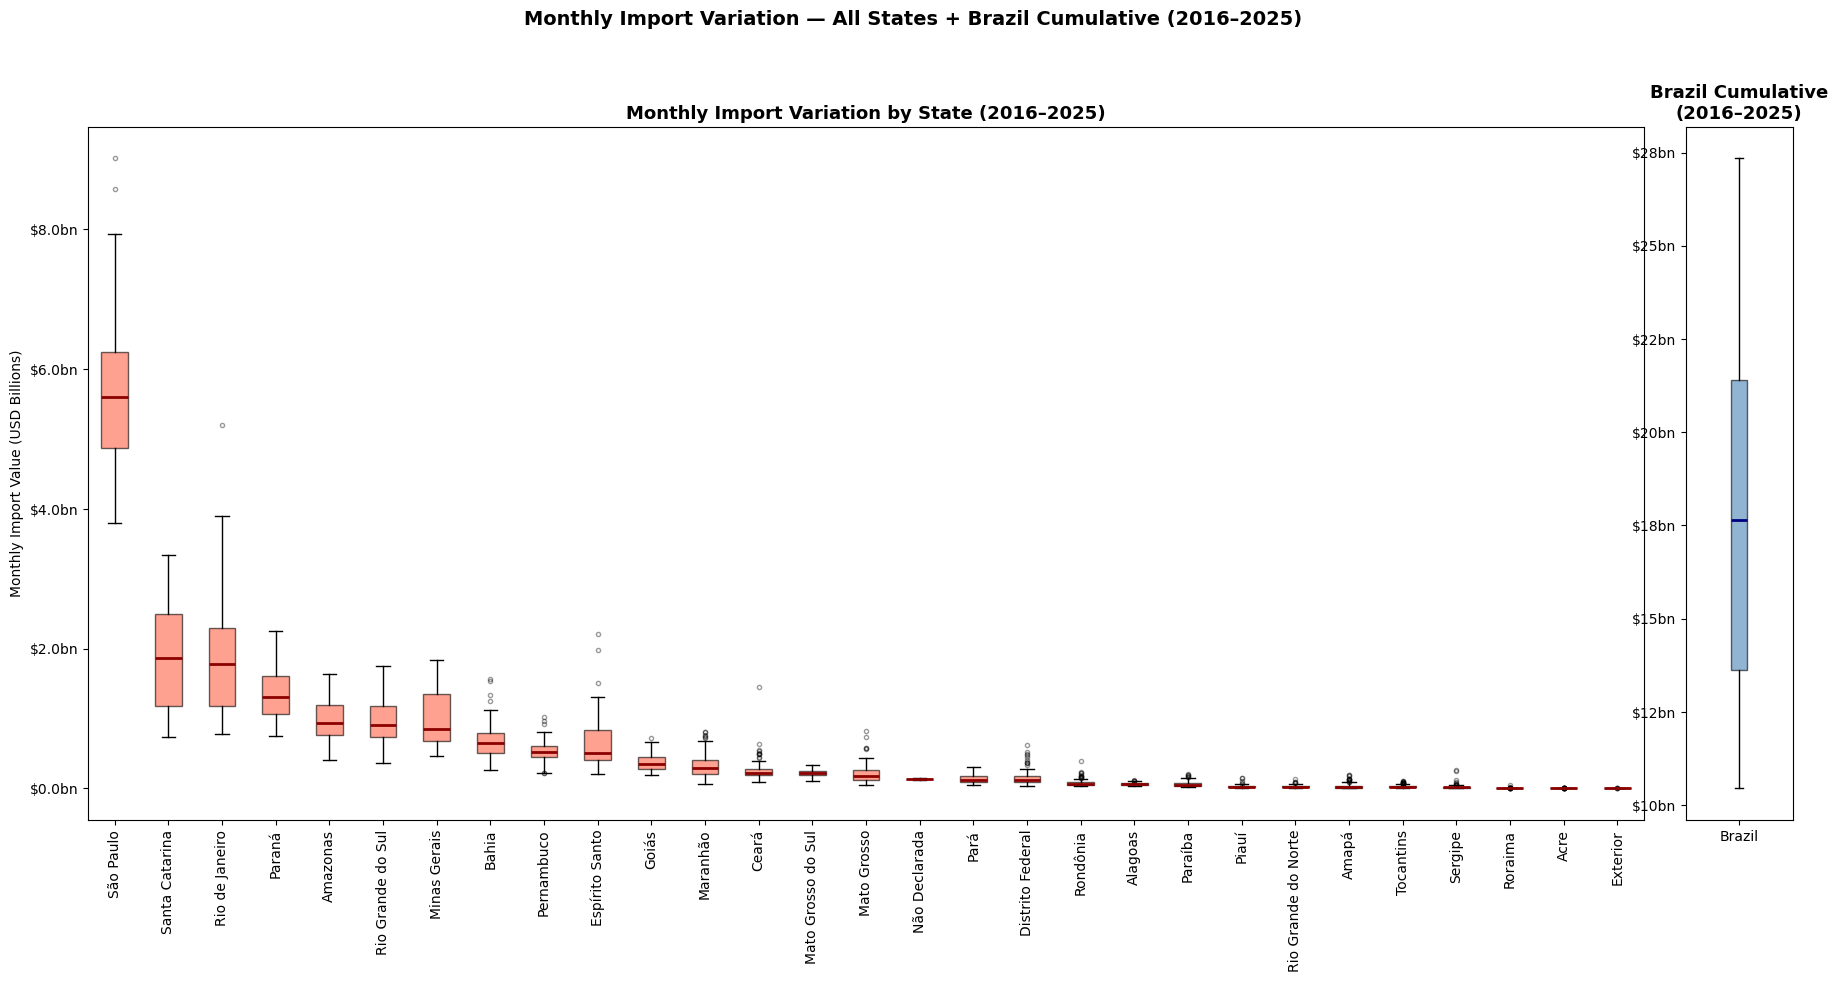


Monthly import summary statistics by state (2016–2025)
                     median  mean   std   min   max
state                                              
São Paulo              5.61  5.63  1.07  3.80  9.02
Santa Catarina         1.87  1.85  0.73  0.74  3.34
Rio de Janeiro         1.78  1.82  0.72  0.77  5.19
Paraná                 1.31  1.35  0.35  0.74  2.25
Amazonas               0.94  0.98  0.29  0.40  1.64
Rio Grande do Sul      0.91  0.96  0.28  0.36  1.74
Minas Gerais           0.85  1.02  0.39  0.46  1.83
Bahia                  0.65  0.68  0.24  0.27  1.56
Pernambuco             0.52  0.53  0.15  0.22  1.03
Espírito Santo         0.51  0.65  0.34  0.21  2.21
Goiás                  0.35  0.37  0.11  0.19  0.72
Maranhão               0.28  0.32  0.17  0.06  0.81
Ceará                  0.22  0.26  0.15  0.10  1.45
Mato Grosso do Sul     0.21  0.22  0.05  0.10  0.34
Mato Grosso            0.17  0.21  0.13  0.05  0.82
Não Declarada          0.13  0.13  0.01  0.11  0.15
Distrito

In [27]:
## Monthly import variation — box plot for all states + Brazil cumulative
## Window: 2016–2025 (last 10 years)

query_monthly_imp_all = f"""
    SELECT i."CO_ANO" AS year,
           i."CO_MES" AS month,
           u.nome_estado AS state,
           u.sigla AS uf,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    WHERE i."CO_ANO" BETWEEN {BOX_START} AND {MAX_YEAR}
    GROUP BY i."CO_ANO", i."CO_MES", u.nome_estado, u.sigla
    ORDER BY u.nome_estado, year, month
"""

df_monthly_imp_all = pd.read_sql(query_monthly_imp_all, engine)
df_monthly_imp_all['imports_usd_bn'] = df_monthly_imp_all['imports_usd'] / 1e9

## Brazil cumulative monthly totals
df_brazil_monthly_imp = (
    df_monthly_imp_all.groupby(['year', 'month'])['imports_usd_bn']
    .sum().reset_index()
)

## Get all states ordered by median monthly imports (descending)
states_all_imp = (
    df_monthly_imp_all.groupby('state')['imports_usd_bn']
    .median().sort_values(ascending=False).index.tolist()
)

## Build data arrays
monthly_data_all_imp    = [df_monthly_imp_all[df_monthly_imp_all['state'] == s]['imports_usd_bn'].values
                           for s in states_all_imp]
brazil_monthly_imp_data = df_brazil_monthly_imp['imports_usd_bn'].values

## Plot — states on the left, Brazil cumulative separated on the right
fig = plt.figure(figsize=(22, 9))
gs  = fig.add_gridspec(1, 2, width_ratios=[len(states_all_imp), 2], wspace=0.05)

ax_states = fig.add_subplot(gs[0])
ax_brazil = fig.add_subplot(gs[1])

## States box plots
bp1 = ax_states.boxplot(
    monthly_data_all_imp,
    labels      = states_all_imp,
    patch_artist= True,
    boxprops    = dict(facecolor='tomato', alpha=0.6),
    medianprops = dict(color='darkred', linewidth=2),
    flierprops  = dict(marker='o', markersize=3, alpha=0.4)
)
ax_states.set_title(f"Monthly Import Variation by State ({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_states.set_ylabel("Monthly Import Value (USD Billions)")
ax_states.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fbn'))
ax_states.tick_params(axis='x', rotation=90)

## Brazil cumulative box plot
bp2 = ax_brazil.boxplot(
    [brazil_monthly_imp_data],
    labels      = ['Brazil'],
    patch_artist= True,
    boxprops    = dict(facecolor='steelblue', alpha=0.6),
    medianprops = dict(color='navy', linewidth=2),
    flierprops  = dict(marker='o', markersize=3, alpha=0.4)
)
ax_brazil.set_title(f"Brazil Cumulative\n({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_brazil.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax_brazil.set_ylabel("")

plt.suptitle(f"Monthly Import Variation — All States + Brazil Cumulative ({BOX_START}–{MAX_YEAR})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2_11_monthly_imp_boxplot_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary statistics
print(f"\nMonthly import summary statistics by state ({BOX_START}–{MAX_YEAR})")
summary_monthly_imp = (
    df_monthly_imp_all.groupby('state')['imports_usd_bn']
    .agg(median='median', mean='mean', std='std', min='min', max='max')
    .round(2)
    .sort_values('median', ascending=False)
)
print(summary_monthly_imp.to_string())
print(f"\nBrazil cumulative monthly imports ({BOX_START}–{MAX_YEAR})")
print(pd.DataFrame(brazil_monthly_imp_data, columns=['imports_usd_bn'])
      .agg(['median', 'mean', 'std', 'min', 'max'])
      .round(2).to_string())

## 2.12 — State Trade Hubs
For each of the top 10 states, what is the export and import hub profile — dominant sectors, top trading partners and trade balance?

In [28]:
## Top export partner per state
query_state_partner_exp = f"""
    SELECT e."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS partner_exports
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."SG_UF_NCM" IN ({top10_states_uf_str})
    GROUP BY e."SG_UF_NCM", p.nome_pais_ing
    ORDER BY e."SG_UF_NCM", partner_exports DESC
"""

## Top import partner per state
query_state_partner_imp = f"""
    SELECT i."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS partner_imports
    FROM imp i
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    AND i."SG_UF_NCM" IN ({top10_states_uf_str})
    GROUP BY i."SG_UF_NCM", p.nome_pais_ing
    ORDER BY i."SG_UF_NCM", partner_imports DESC
"""

df_sp_exp = pd.read_sql(query_state_partner_exp, engine)
df_sp_imp = pd.read_sql(query_state_partner_imp, engine)

## Keep only top partner per state
top_exp_partner = df_sp_exp.groupby('uf').first().reset_index()[['uf', 'top_export_partner']]
top_imp_partner = df_sp_imp.groupby('uf').first().reset_index()[['uf', 'top_import_partner']]

## Top export sector per state (from 2.6)
top_exp_sector = (
    df_exp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2']]
    .rename(columns={'descricao_sh2': 'top_export_sector'})
)

## Top import sector per state (from 2.7)
top_imp_sector = (
    df_imp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'imports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2']]
    .rename(columns={'descricao_sh2': 'top_import_sector'})
)

## Assemble hub profile
df_hub = df_state.head(10)[['uf', 'state', 'region', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']]
df_hub = df_hub.merge(top_exp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_imp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_exp_sector,  on='uf', how='left')
df_hub = df_hub.merge(top_imp_sector,  on='uf', how='left')

print(f"State Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_hub.iterrows():
    print(f"\n  {row['state']} ({row['uf']}) — {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

State Trade Hub Profiles (2025)

  São Paulo (SP) — REGIAO SUDESTE
  ──────────────────────────────────────────────────
  Exports:              $71.39bn
  Imports:              $86.50bn
  Trade Balance:        $-15.11bn  (DEFICIT)
  Top Export Sector:    Açúcares e produtos de confeitaria
  Top Import Sector:    Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes
  Top Export Partner:   United States
  Top Import Partner:   China

  Rio de Janeiro (RJ) — REGIAO SUDESTE
  ──────────────────────────────────────────────────
  Exports:              $48.98bn
  Imports:              $32.17bn
  Trade Balance:        $16.80bn  (SURPLUS)
  Top Export Sector:    Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais
  Top Import Sector:    Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes
  Top Export Partner:   China
  Top Import Partner:   United States

  Minas Ger

C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\906527582.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'exports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_16036\906527582.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'imports_usd'))


## 2.13 — Regional Trade Hubs
Aggregating the state hub profiles to the regional level — what does each macro-region specialise in, and what are its key trade relationships?

In [30]:
## Top export sector per region
query_region_exp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2 AS top_export_sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, s.descricao_sh2
    ORDER BY u.nome_regiao, exports_usd DESC
"""

## Top import sector per region
query_region_imp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2 AS top_import_sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, s.descricao_sh2
    ORDER BY u.nome_regiao, imports_usd DESC
"""

## Top export partner per region
query_region_exp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""

## Top import partner per region
query_region_imp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, imports_usd DESC
"""

df_reg_exp_sec  = pd.read_sql(query_region_exp_sector,  engine)
df_reg_imp_sec  = pd.read_sql(query_region_imp_sector,  engine)
df_reg_exp_part = pd.read_sql(query_region_exp_partner, engine)
df_reg_imp_part = pd.read_sql(query_region_imp_partner, engine)

top_reg_exp_sec  = df_reg_exp_sec.groupby('region').first().reset_index()[['region', 'top_export_sector']]
top_reg_imp_sec  = df_reg_imp_sec.groupby('region').first().reset_index()[['region', 'top_import_sector']]
top_reg_exp_part = df_reg_exp_part.groupby('region').first().reset_index()[['region', 'top_export_partner']]
top_reg_imp_part = df_reg_imp_part.groupby('region').first().reset_index()[['region', 'top_import_partner']]

## Regional totals
df_region_totals = (
    df_state.groupby('region')
    .agg(exports_usd_bn=('exports_usd_bn', 'sum'),
         imports_usd_bn=('imports_usd_bn', 'sum'),
         balance_usd_bn=('balance_usd_bn', 'sum'))
    .reset_index()
)

df_region_hub = df_region_totals.copy()
df_region_hub = df_region_hub.merge(top_reg_exp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_exp_part, on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_part, on='region', how='left')

print(f"Regional Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_region_hub.sort_values('exports_usd_bn', ascending=False).iterrows():
    print(f"\n  {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

Regional Trade Hub Profiles (2025)

  REGIAO SUDESTE
  ──────────────────────────────────────────────────
  Exports:              $176.71bn
  Imports:              $150.81bn
  Trade Balance:        $25.89bn  (SURPLUS)
  Top Export Sector:    Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais
  Top Import Sector:    Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes
  Top Export Partner:   China
  Top Import Partner:   China

  REGIAO SUL
  ──────────────────────────────────────────────────
  Exports:              $57.38bn
  Imports:              $67.52bn
  Trade Balance:        $-10.15bn  (DEFICIT)
  Top Export Sector:    Carnes e miudezas, comestíveis
  Top Import Sector:    Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes
  Top Export Partner:   China
  Top Import Partner:   China

  REGIAO CENTRO OESTE
  ─────────────────────────────────────────────

## 2.14 — Commodities vs Processed Products by State and Region

> ⚠️ **PLACEHOLDER — Requires classification table**
>
> This cell requires a mapping table that classifies each NCM code (or SH2/SH4 code) as either a **raw commodity** or a **processed/manufactured product**. This classification does not exist in the current database and needs to be created before this analysis can be run.
>
> **Options for implementation (to be decided):**
> - Use `ncm_fat_agreg` categories and define a mapping of which `codigo_fat_agreg` values correspond to commodities vs processed goods
> - Use SH2 codes and manually classify each of the ~100 SH2 chapters as commodity or processed
> - Use `ncm_cgce_n1` classification which has a built-in economic use categorisation
> - Source an external commodity classification list (e.g. IMF primary commodity list) and map to NCM codes
>
> **What this cell will produce once implemented:**
> - % of exports classified as commodity vs processed for each state
> - % of exports classified as commodity vs processed for each region
> - Volume (USD bn) of commodity vs processed exports by state and region
> - Time series showing whether Brazil's export mix has shifted from commodities toward processed goods over 1997–2025

```python
## TO BE IMPLEMENTED — add commodity classification logic here
## Expected inputs: a DataFrame or SQL table mapping ncm_code -> 'commodity' or 'processed'
## Expected outputs: stacked bar charts and summary tables by state and region
```

## 2.15 — Key Findings

> *To be completed after running all cells above. Use the outline below as a guide.*

### Structure
1. **Which states dominate Brazilian trade** — top 3 exporting and importing states and their share of national totals
2. **Net exporters vs net importers** — how many states run surpluses vs deficits and any regional pattern
3. **State balance evolution** — which states were most affected by the 2011–2016 decline and which were resilient
4. **Regional specialisation** — what each macro-region specialises in based on hub profiles
5. **China dependency at state level** — which states are above and below the 28.7% national average, and what that implies
6. **Monthly volatility** — which states show the highest seasonal variation and what that means for market entry timing
7. **Limitations** — note any states with missing or low data, flag commodity vs processed analysis as pending
8. **What comes next** — Step 3 municipality-level hotspots